In [2]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
import math
import random
import seaborn as sns
import matplotlib.pyplot as plt
# Sirve para medir la velocidad de una función
import time
%load_ext line_profiler
import sys
sys.path.insert(1, '/Users/damian/Documents/Tesis maestria/Bootstraps_codigos_bases/Codigos/Funciones_utiles')
import funciones_aux_bootstrap as fab
from matplotlib import legend_handler

# Fijamos el estilo de la gráfica
plt.style.use('petroff10')

In [3]:
# Importamos los datos para el análisis
df_act_yuc_i=pd.read_csv(r"/Users/damian/Documents/Tesis maestria/Bootstraps_codigos_bases/Bases/Base elecciones analsis/base_elecciones_yuc_analsis.csv", index_col=0)
df_act_yuc_i

,ID ESTADO,NOMBRE ESTADO,DISTRITO,SECCION,CASILLA,ID CASILLA,ESTATUS ACTA,PAN,PRI,PRD,...,CANDIDATOS NO REGISTRADOS,VOTOS NULOS,LISTA NOMINAL,TOTAL,PARTICIPACIÓN,JOAQUIN_DIAZ_MENA,RENAN_BARRERA_CONCHA,VIDA_ARAVARI_GOMEZ_HERRERA,YAMIL_JASMIN_LOPEZ_MANRIQUE,VOTOS_NULOS_CAND_NO_REGIS
0,31,YUCATÁN,12,1,'0001B1,1,COMPUTADA,171.0,107.0,3.0,...,0.0,12.0,596.0,532.0,0.892617,209.0,290.0,18.0,3.0,12.0
1,31,YUCATÁN,12,1,'0001C1,2,COMPUTADA,177.0,104.0,0.0,...,0.0,11.0,596.0,547.0,0.917785,208.0,299.0,29.0,0.0,11.0
2,31,YUCATÁN,12,1,'0001C2,3,COMPUTADA,176.0,100.0,1.0,...,0.0,13.0,595.0,542.0,0.910924,228.0,289.0,11.0,1.0,13.0
3,31,YUCATÁN,12,2,'0002B1,4,COMPUTADA,46.0,33.0,2.0,...,0.0,3.0,174.0,162.0,0.931034,71.0,79.0,7.0,2.0,3.0
4,31,YUCATÁN,12,4,'0004B1,6,COMPUTADA,110.0,96.0,7.0,...,0.0,14.0,550.0,513.0,0.932727,275.0,207.0,10.0,7.0,14.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2836,31,YUCATÁN,3,1195,'1195V1,2967,COMPUTADA,2.0,0.0,0.0,...,0.0,0.0,0.0,2.0,0.000000,0.0,2.0,0.0,0.0,0.0
2837,31,YUCATÁN,5,1197,'1197V1,2969,COMPUTADA,2.0,1.0,0.0,...,0.0,0.0,0.0,5.0,0.000000,2.0,3.0,0.0,0.0,0.0
2838,31,YUCATÁN,8,1199,'1199V1,2971,COMPUTADA,2.0,0.0,0.0,...,0.0,0.0,0.0,3.0,0.000000,1.0,2.0,0.0,0.0,0.0
2839,31,YUCATÁN,9,1200,'1200V1,2972,COMPUTADA,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.000000,1.0,0.0,0.0,0.0,0.0


In [4]:
# Datos reales de la proporción
prop_reales=df_act_yuc_i[["JOAQUIN_DIAZ_MENA","RENAN_BARRERA_CONCHA","VIDA_ARAVARI_GOMEZ_HERRERA","YAMIL_JASMIN_LOPEZ_MANRIQUE","VOTOS_NULOS_CAND_NO_REGIS"]].sum()/df_act_yuc_i[["JOAQUIN_DIAZ_MENA","RENAN_BARRERA_CONCHA","VIDA_ARAVARI_GOMEZ_HERRERA","YAMIL_JASMIN_LOPEZ_MANRIQUE","VOTOS_NULOS_CAND_NO_REGIS"]].sum().sum()
prop_reales

JOAQUIN_DIAZ_MENA              0.515125
RENAN_BARRERA_CONCHA           0.421366
VIDA_ARAVARI_GOMEZ_HERRERA     0.036792
YAMIL_JASMIN_LOPEZ_MANRIQUE    0.005249
VOTOS_NULOS_CAND_NO_REGIS      0.021467
dtype: float64

In [5]:
b=df_act_yuc_i[["JOAQUIN_DIAZ_MENA","RENAN_BARRERA_CONCHA","VIDA_ARAVARI_GOMEZ_HERRERA","YAMIL_JASMIN_LOPEZ_MANRIQUE","VOTOS_NULOS_CAND_NO_REGIS"]]
b

,JOAQUIN_DIAZ_MENA,RENAN_BARRERA_CONCHA,VIDA_ARAVARI_GOMEZ_HERRERA,YAMIL_JASMIN_LOPEZ_MANRIQUE,VOTOS_NULOS_CAND_NO_REGIS
0,209.0,290.0,18.0,3.0,12.0
1,208.0,299.0,29.0,0.0,11.0
2,228.0,289.0,11.0,1.0,13.0
3,71.0,79.0,7.0,2.0,3.0
4,275.0,207.0,10.0,7.0,14.0
...,...,...,...,...,...
2836,0.0,2.0,0.0,0.0,0.0
2837,2.0,3.0,0.0,0.0,0.0
2838,1.0,2.0,0.0,0.0,0.0
2839,1.0,0.0,0.0,0.0,0.0


In [6]:
# Coeficiente de variación
b.div(b.sum(axis=1), axis=0).std(0)/b.div(b.sum(axis=1), axis=0).mean(0)

JOAQUIN_DIAZ_MENA              0.255065
RENAN_BARRERA_CONCHA           0.329079
VIDA_ARAVARI_GOMEZ_HERRERA     0.979911
YAMIL_JASMIN_LOPEZ_MANRIQUE    2.298325
VOTOS_NULOS_CAND_NO_REGIS      1.070380
dtype: float64

## Comparación bootstraps sin estratificar

In [7]:
# Leemos las bases

# Base de bootstrap por casillas sin estratificar
df_boostraps_c_s_e=pd.read_csv(r"/Users/damian/Documents/Tesis maestria/Bootstraps_codigos_bases/Bases finales rep/Bootstrap por casillas/Distintas_muestras_casillas_bootstrap_sin_est_f_1.csv", index_col=0)
# Base de bootstrap por votos (submuestreo) método 1
df_boostraps_votos_se=pd.read_csv(r"/Users/damian/Documents/Tesis maestria/Bootstraps_codigos_bases/Bases finales rep/Bootstrap votos/Metodo 2/Distintas_muestras_submuestras_bootstrap_votos_met_2_sin_est_f_1.csv", index_col=0)


## Reducción del error

In [8]:
# Por casillas
1-df_boostraps_c_s_e["Error_maximo_mediana"].min()/df_boostraps_c_s_e["Error_maximo_mediana"].max()

np.float64(0.5391096616175091)

In [9]:
# Por casillas luego votos
b=df_boostraps_votos_se.groupby('Tamaño_submuestra_votos').agg({'Error_maximo_mediana':['max','min']})
b.columns=b.columns.map('_'.join)
b=b.reset_index()
b["Reduccion"]=1-b["Error_maximo_mediana_min"]/b["Error_maximo_mediana_max"]
b

,Tamaño_submuestra_votos,Error_maximo_mediana_max,Error_maximo_mediana_min,Reduccion
0,500,0.011172,0.005370,0.519299
1,1000,0.010349,0.005343,0.483691
2,2000,0.011880,0.005119,0.569096
3,5000,0.011266,0.005342,0.525842
4,10000,0.010593,0.005531,0.477884
5,20000,0.010973,0.005063,0.538640


## Reducción intervalo más largo

In [10]:
# Por casillas
1-df_boostraps_c_s_e["Intervalo_M_grande_inter_mediana"].min()/df_boostraps_c_s_e["Intervalo_M_grande_inter_mediana"].max()

np.float64(0.46589893084468936)

In [11]:
# Por casillas luego votos
a=df_boostraps_votos_se.groupby('Tamaño_submuestra_votos').agg({'Intervalo_M_grande_inter_mediana':['max','min']})
a.columns=a.columns.map('_'.join)
a=a.reset_index()
a["Reduccion"]=1-a["Intervalo_M_grande_inter_mediana_min"]/a["Intervalo_M_grande_inter_mediana_max"]
a

,Tamaño_submuestra_votos,Intervalo_M_grande_inter_mediana_max,Intervalo_M_grande_inter_mediana_min,Reduccion
0,500,0.123107,0.122495,0.004974
1,1000,0.087031,0.086576,0.005224
2,2000,0.061528,0.060915,0.009958
3,5000,0.038715,0.037839,0.022626
4,10000,0.027231,0.025995,0.045385
5,20000,0.018997,0.017153,0.097073


## Gráficas

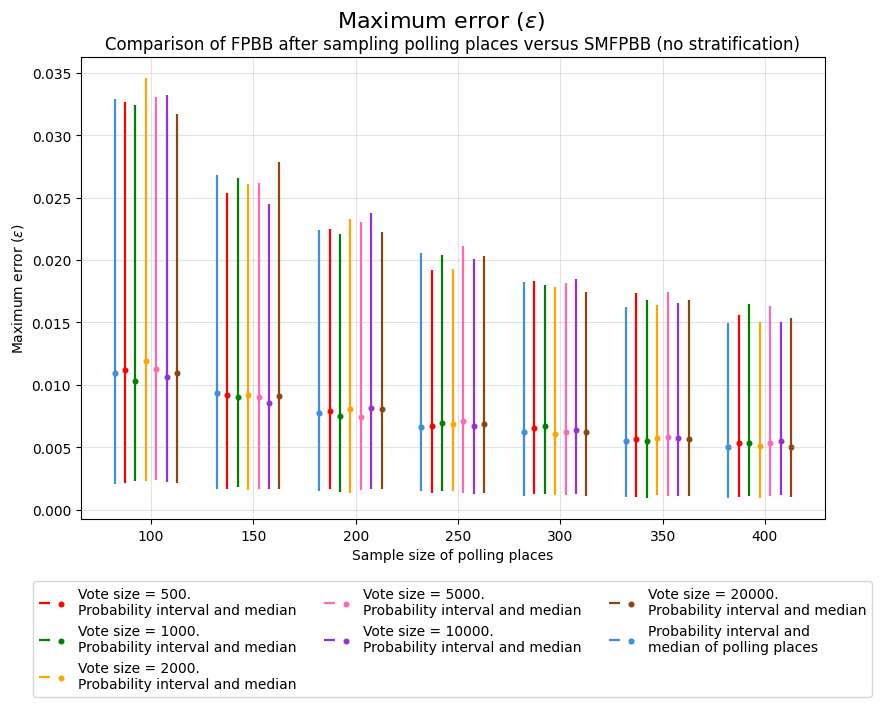

In [12]:
# Tamaño de la gráfica
fig = plt.figure(figsize=(9.6, 6), dpi=100)
# Para guardar la imagen
#fig = plt.figure(figsize=(9.6, 6), dpi=350)
ax = fig.add_subplot(111)

# Colores para la gráfica
colors_plot = ["red", "green", "orange", "hotpink", "darkorchid", "saddlebrown", "mediumturquoise"]

# Lista de los labels de las gráficas
labels_votos = []

# Lista para guardar las gráficas
lista_graficas = []

# Para que no se crucen las líneas
offset = 5.1

# Primero hacemos un for para crear los valores para que no crucen las líneas
valores_x_grafica=[]
for ind_j, j in enumerate(df_boostraps_votos_se["Tamaño_submuestra_votos"].unique()):
    k = 0
    for ind_i, i in enumerate(df_boostraps_votos_se["Tamaño_muestra_casillas"].unique()):

        # Slightly offset the x position for each subcategory
        valores_x_grafica.append( i + (ind_j - (len(df_boostraps_votos_se["Tamaño_submuestra_votos"].unique())+1) / 2) * offset)


# Para graficar todos las rectas de los votos
for ind_j, j in enumerate(df_boostraps_votos_se["Tamaño_submuestra_votos"].unique()):
    l=0
    for ind_i, i in enumerate(df_boostraps_votos_se["Tamaño_muestra_casillas"].unique()):
              
        if l==0:
            # Slightly offset the x position for each subcategory
            x_position = i + (ind_j+1 - (len(df_boostraps_votos_se["Tamaño_submuestra_votos"].unique())+1) / 2) * offset

            # Guardamos en lista los labels
            labels_votos.append(f"Vote size = {j}. \nProbability interval and median")
            linea_1=ax.vlines(
                x_position,
                df_boostraps_votos_se[
                    (df_boostraps_votos_se["Tamaño_muestra_casillas"] == i)
                    & (df_boostraps_votos_se["Tamaño_submuestra_votos"] == j)
                ]["Error_maximo_q_025"].iloc[0],
                df_boostraps_votos_se[
                    (df_boostraps_votos_se["Tamaño_muestra_casillas"] == i)
                    & (df_boostraps_votos_se["Tamaño_submuestra_votos"] == j)
                ]["Error_maximo_q_975"].iloc[0],
                color=colors_plot[ind_j],
                linestyle="solid",
                label=f"Muestra votos = {j} (sin estratificar)",
                linewidth=1.6
            )
            punto_1=plt.scatter(x_position, df_boostraps_votos_se[
                    (df_boostraps_votos_se["Tamaño_muestra_casillas"] == i)
                    & (df_boostraps_votos_se["Tamaño_submuestra_votos"] == j)
                ]["Error_maximo_mediana"].iloc[0], color=colors_plot[ind_j], s=11)
            
            # Para que aparezcan los nombres
            lista_graficas.append((linea_1, punto_1))


        else:
            # Slightly offset the x position for each subcategory
            x_position = i + (ind_j+1 - (len(df_boostraps_votos_se["Tamaño_submuestra_votos"].unique())+1) / 2) * offset

            # Guardamos en lista los labels
            #labels_votos.append(f"Sample size of votes = {j}. \nProbability interval and median")
            ax.vlines(
                x_position,
                df_boostraps_votos_se[
                    (df_boostraps_votos_se["Tamaño_muestra_casillas"] == i)
                    & (df_boostraps_votos_se["Tamaño_submuestra_votos"] == j)
                ]["Error_maximo_q_025"].iloc[0],
                df_boostraps_votos_se[
                    (df_boostraps_votos_se["Tamaño_muestra_casillas"] == i)
                    & (df_boostraps_votos_se["Tamaño_submuestra_votos"] == j)
                ]["Error_maximo_q_975"].iloc[0],
                color=colors_plot[ind_j],
                linestyle="solid",
                linewidth=1.6
            )
            plt.scatter(x_position, df_boostraps_votos_se[
            (df_boostraps_votos_se["Tamaño_muestra_casillas"] == i)
            & (df_boostraps_votos_se["Tamaño_submuestra_votos"] == j)
        ]["Error_maximo_mediana"].iloc[0], color=colors_plot[ind_j], s=11)
            
        l=l+1


k=0

# Las gráficas de los intervalos de probabilidad de las casillas
for ind_i, i in enumerate(df_boostraps_c_s_e["Tamaño_muestra_casillas"].unique()):

    if k==0:
        x_position = valores_x_grafica[ind_i]
        # Guardamos en lista los labels
        labels_votos.append(f"Probability interval and \nmedian of polling places")
        linea_2=ax.vlines(
            x_position,
            df_boostraps_c_s_e[
                (df_boostraps_c_s_e["Tamaño_muestra_casillas"] == i)
            ]["Error_maximo_q_025"].iloc[0],
            df_boostraps_c_s_e[
                (df_boostraps_c_s_e["Tamaño_muestra_casillas"] == i)
            ]["Error_maximo_q_975"].iloc[0],
            linestyle="solid",
            label=f"Polling places",
            linewidth=1.6
        )
        # Graficamos las medianas
        punto_2=ax.scatter(x_position,df_boostraps_c_s_e[(df_boostraps_c_s_e["Tamaño_muestra_casillas"]==i)]["Error_maximo_mediana"].iloc[0], color='C0', s=12)
        # Para que aparezcan los nombres
        lista_graficas.append((linea_2, punto_2))
    else:
        x_position = valores_x_grafica[ind_i]
        # Guardamos en lista los labels
        #labels_votos.append(f"Probability interval of \npolling places")
        ax.vlines(
            x_position,
            df_boostraps_c_s_e[
                (df_boostraps_c_s_e["Tamaño_muestra_casillas"] == i)
            ]["Error_maximo_q_025"].iloc[0],
            df_boostraps_c_s_e[
                (df_boostraps_c_s_e["Tamaño_muestra_casillas"] == i)
            ]["Error_maximo_q_975"].iloc[0],
            linestyle="solid",
            linewidth=1.6
        )
        # Graficamos las medianas
        ax.scatter(x_position,df_boostraps_c_s_e[(df_boostraps_c_s_e["Tamaño_muestra_casillas"]==i)]["Error_maximo_mediana"].iloc[0], color='C0', s=12)
    k=l+1


# Juntamos los títulos y las leyendas con un nombre
plt.legend(bbox_to_anchor=(0.5, -0.12), ncol=2, loc="upper center", numpoints=1)

lgnd = ax.legend(lista_graficas, labels_votos, bbox_to_anchor=(0.5, -0.12), ncol=3, loc="upper center", numpoints=1, handler_map = {tuple: legend_handler.HandlerTuple(None)})

plt.suptitle("Maximum error ($\\epsilon$)", fontsize=16, y=0.96)
plt.title("Comparison of FPBB after sampling polling places versus SMFPBB (no stratification)")

plt.xlabel("Sample size of polling places")
plt.ylabel("Maximum error ($\\epsilon$)")

plt.grid(alpha=0.35);
plt.savefig(r"/Users/damian/Documents/Tesis maestria/Imagenes/Casillas_vs_casillas_sub_votos_m_2/No estratificado/Error_casillas_sub_votos_vs_casillas_m_2.png", bbox_inches='tight',dpi=300);


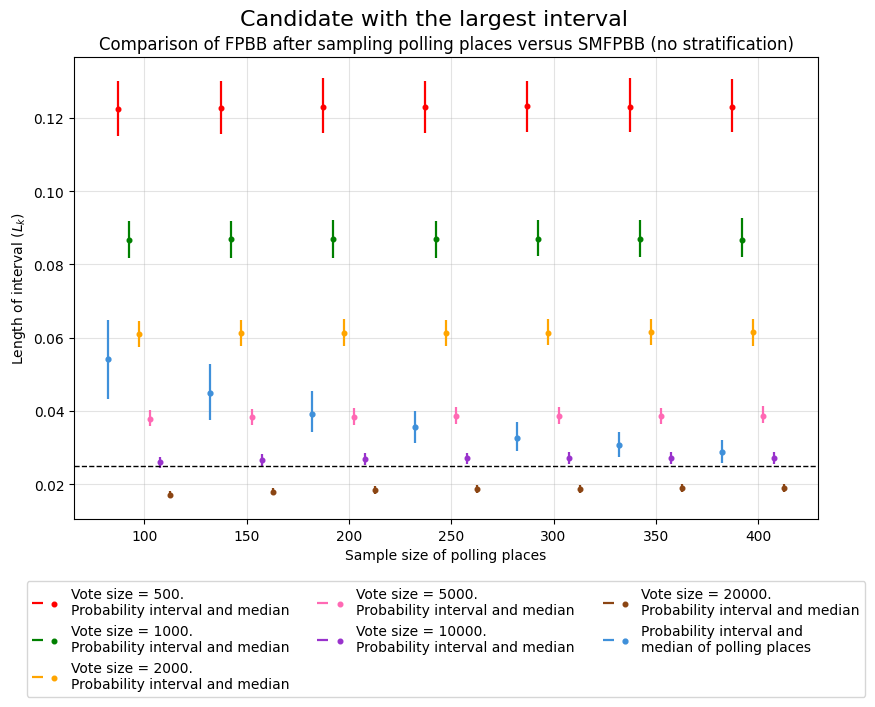

In [18]:
# Tamaño de la gráfica
fig = plt.figure(figsize=(9.6, 6), dpi=100)

# Para guardar la imagen
#fig = plt.figure(figsize=(9.6, 6), dpi=350)
ax = fig.add_subplot(111)

# Colores para la gráfica
colors_plot = ["red", "green", "orange", "hotpink", "darkorchid", "saddlebrown", "mediumturquoise"]

# Lista de los labels de las gráficas
labels_votos = []

# Lista para guardar las gráficas
lista_graficas = []

# Para que no se crucen las líneas
offset = 5.1

# Primero hacemos un for para crear los valores para que no crucen las líneas
valores_x_grafica=[]
for ind_j, j in enumerate(df_boostraps_votos_se["Tamaño_submuestra_votos"].unique()):
    k = 0
    for ind_i, i in enumerate(df_boostraps_votos_se["Tamaño_muestra_casillas"].unique()):

        # Slightly offset the x position for each subcategory
        valores_x_grafica.append( i + (ind_j - (len(df_boostraps_votos_se["Tamaño_submuestra_votos"].unique())+1) / 2) * offset)


# Para graficar todos las rectas de los votos
for ind_j, j in enumerate(df_boostraps_votos_se["Tamaño_submuestra_votos"].unique()):
    l=0
    for ind_i, i in enumerate(df_boostraps_votos_se["Tamaño_muestra_casillas"].unique()):
              
        if l==0:
            # Slightly offset the x position for each subcategory
            x_position = i + (ind_j+1 - (len(df_boostraps_votos_se["Tamaño_submuestra_votos"].unique())+1) / 2) * offset

            # Guardamos en lista los labels
            labels_votos.append(f"Vote size = {j}. \nProbability interval and median")
            linea_1=ax.vlines(
                x_position,
                df_boostraps_votos_se[
                    (df_boostraps_votos_se["Tamaño_muestra_casillas"] == i)
                    & (df_boostraps_votos_se["Tamaño_submuestra_votos"] == j)
                ]["Intervalo_M_grande_inter_q_025"].iloc[0],
                df_boostraps_votos_se[
                    (df_boostraps_votos_se["Tamaño_muestra_casillas"] == i)
                    & (df_boostraps_votos_se["Tamaño_submuestra_votos"] == j)
                ]["Intervalo_M_grande_inter_q_975"].iloc[0],
                color=colors_plot[ind_j],
                linestyle="solid",
                label=f"Muestra votos = {j} (sin estratificar)",
                linewidth=1.6
            )
            punto_1=plt.scatter(x_position, df_boostraps_votos_se[
                    (df_boostraps_votos_se["Tamaño_muestra_casillas"] == i)
                    & (df_boostraps_votos_se["Tamaño_submuestra_votos"] == j)
                ]["Intervalo_M_grande_inter_mediana"].iloc[0], color=colors_plot[ind_j], s=11)
            
            # Para que aparezcan los nombres
            lista_graficas.append((linea_1, punto_1))


        else:
            # Slightly offset the x position for each subcategory
            x_position = i + (ind_j+1 - (len(df_boostraps_votos_se["Tamaño_submuestra_votos"].unique())+1) / 2) * offset

            # Guardamos en lista los labels
            #labels_votos.append(f"Sample size of votes = {j}. \nProbability interval and median")
            ax.vlines(
                x_position,
                df_boostraps_votos_se[
                    (df_boostraps_votos_se["Tamaño_muestra_casillas"] == i)
                    & (df_boostraps_votos_se["Tamaño_submuestra_votos"] == j)
                ]["Intervalo_M_grande_inter_q_025"].iloc[0],
                df_boostraps_votos_se[
                    (df_boostraps_votos_se["Tamaño_muestra_casillas"] == i)
                    & (df_boostraps_votos_se["Tamaño_submuestra_votos"] == j)
                ]["Intervalo_M_grande_inter_q_975"].iloc[0],
                color=colors_plot[ind_j],
                linestyle="solid",
                linewidth=1.6
            )
            plt.scatter(x_position, df_boostraps_votos_se[
            (df_boostraps_votos_se["Tamaño_muestra_casillas"] == i)
            & (df_boostraps_votos_se["Tamaño_submuestra_votos"] == j)
        ]["Intervalo_M_grande_inter_mediana"].iloc[0], color=colors_plot[ind_j], s=11)
            
        l=l+1


k=0

# Las gráficas de los intervalos de probabilidad de las casillas
for ind_i, i in enumerate(df_boostraps_c_s_e["Tamaño_muestra_casillas"].unique()):

    if k==0:
        x_position = valores_x_grafica[ind_i]
        # Guardamos en lista los labels
        labels_votos.append(f"Probability interval and \nmedian of polling places")
        linea_2=ax.vlines(
            x_position,
            df_boostraps_c_s_e[
                (df_boostraps_c_s_e["Tamaño_muestra_casillas"] == i)
            ]["Intervalo_M_grande_inter_q_025"].iloc[0],
            df_boostraps_c_s_e[
                (df_boostraps_c_s_e["Tamaño_muestra_casillas"] == i)
            ]["Intervalo_M_grande_inter_q_975"].iloc[0],
            linestyle="solid",
            label=f"Polling places",
            linewidth=1.6
        )
        # Graficamos las medianas
        punto_2=ax.scatter(x_position,df_boostraps_c_s_e[(df_boostraps_c_s_e["Tamaño_muestra_casillas"]==i)]["Intervalo_M_grande_inter_mediana"].iloc[0], color='C0', s=12)
        # Para que aparezcan los nombres
        lista_graficas.append((linea_2, punto_2))
    else:
        x_position = valores_x_grafica[ind_i]
        # Guardamos en lista los labels
        #labels_votos.append(f"Probability interval of \npolling places")
        ax.vlines(
            x_position,
            df_boostraps_c_s_e[
                (df_boostraps_c_s_e["Tamaño_muestra_casillas"] == i)
            ]["Intervalo_M_grande_inter_q_025"].iloc[0],
            df_boostraps_c_s_e[
                (df_boostraps_c_s_e["Tamaño_muestra_casillas"] == i)
            ]["Intervalo_M_grande_inter_q_975"].iloc[0],
            linestyle="solid",
            linewidth=1.6
        )
        # Graficamos las medianas
        ax.scatter(x_position,df_boostraps_c_s_e[(df_boostraps_c_s_e["Tamaño_muestra_casillas"]==i)]["Intervalo_M_grande_inter_mediana"].iloc[0], color='C0', s=12)
    k=l+1


# Juntamos los títulos y las leyendas con un nombre
plt.legend(bbox_to_anchor=(0.5, -0.12), ncol=2, loc="upper center", numpoints=1)
plt.axhline(y=0.025, linewidth=1, color='black', ls='--');

lgnd = ax.legend(lista_graficas, labels_votos, bbox_to_anchor=(0.5, -0.12), ncol=3, loc="upper center", numpoints=1, handler_map = {tuple: legend_handler.HandlerTuple(None)})

plt.suptitle('Candidate with the largest interval', fontsize=16, y=0.96)
plt.title("Comparison of FPBB after sampling polling places versus SMFPBB (no stratification)")

plt.xlabel('Sample size of polling places')
plt.ylabel('Length of interval ($L_{k}$)');
plt.grid(alpha=0.35);

plt.savefig(r"/Users/damian/Documents/Tesis maestria/Imagenes/Casillas_vs_casillas_sub_votos_m_2/No estratificado/Intervalo_mas_largo_casillas_sub_votos_vs_casillas_m_2.png", bbox_inches='tight',dpi=300);


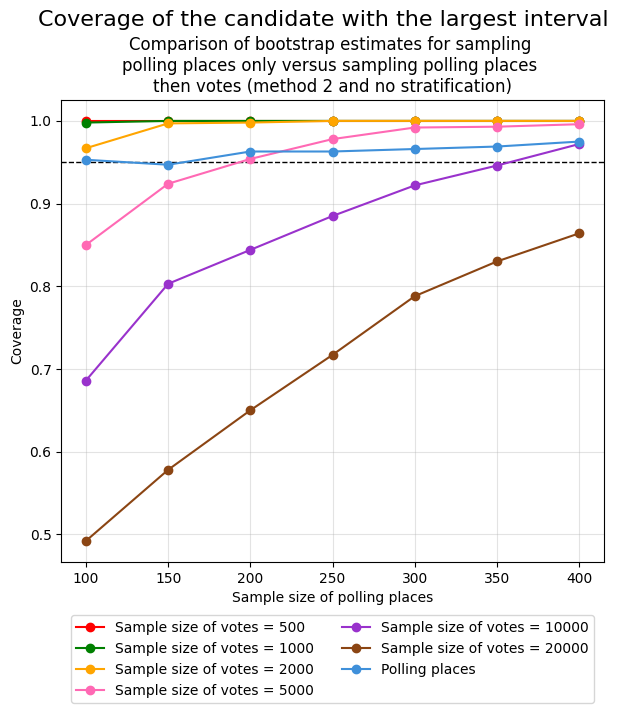

In [11]:
# Tamaño de la gráfica
fig = plt.figure(figsize=(7, 6), dpi=100)

# Colores para la gráfica
colors_plot = ["red", "green", "orange", "hotpink", "darkorchid", "saddlebrown", "mediumturquoise"]
plt.axhline(y=0.95, linewidth=1, color='black', ls='--');
l=0
# Para graficar todos las rectas de los votos
for ind_j, j in enumerate(df_boostraps_votos_se["Tamaño_submuestra_votos"].unique()):     
        plt.plot(df_boostraps_votos_se[(df_boostraps_votos_se["Tamaño_submuestra_votos"] == j)]["Tamaño_muestra_casillas"], 
                 df_boostraps_votos_se[(df_boostraps_votos_se["Tamaño_submuestra_votos"] == j)]["Intervalo_M_grande_candidato_cob"],
                 color=colors_plot[ind_j], label=f'Sample size of votes = {j}', linestyle='solid',  marker='o')
        
# La gráfica de las casillas
plt.plot(df_boostraps_c_s_e["Tamaño_muestra_casillas"], df_boostraps_c_s_e["Intervalo_M_grande_candidato_cob"], color='C0', marker='o', label='Polling places')

plt.suptitle('Coverage of the candidate with the largest interval', fontsize=16, y=1.03)
plt.title('Comparison of bootstrap estimates for sampling \npolling places only versus sampling polling places \nthen votes (method 2 and no stratification)');
plt.ylabel(ylabel='Coverage');
plt.xlabel('Sample size of polling places')

# Cambiamos el nombre de la leyenda
plt.legend(title='Votos o casillas');
plt.grid(alpha=0.35);


# Juntamos los títulos y las leyendas con un nombre
plt.legend( bbox_to_anchor=(0.5, -0.1), loc="upper center", shadow=False, ncol=2);

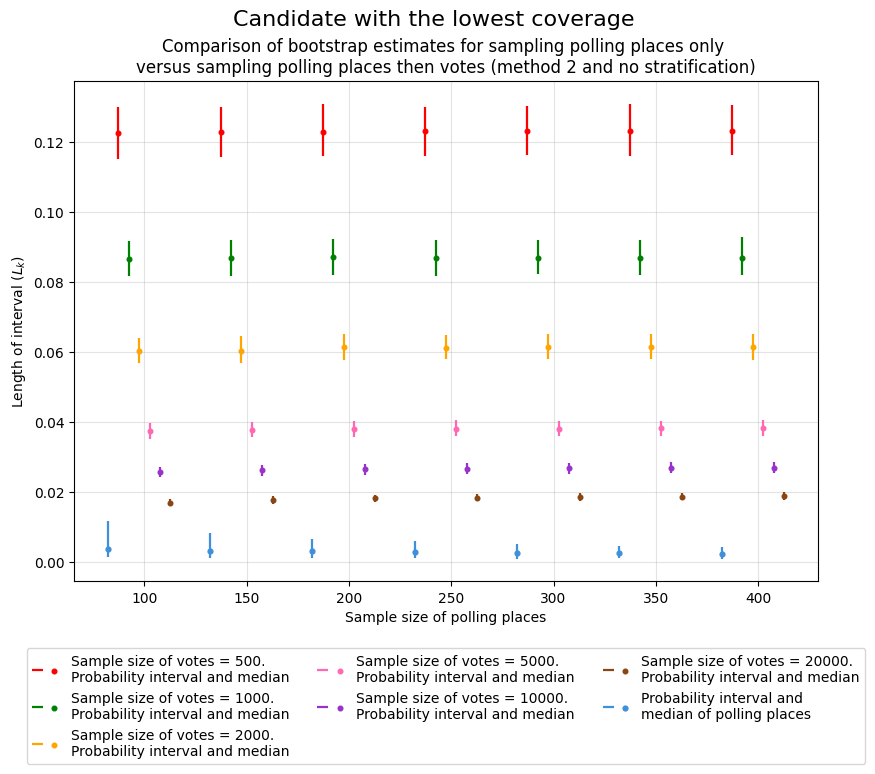

In [ ]:
# Tamaño de la gráfica
fig = plt.figure(figsize=(9.6, 6.5), dpi=100)
ax = fig.add_subplot(111)

# Colores para la gráfica
colors_plot = ["red", "green", "orange", "hotpink", "darkorchid", "saddlebrown", "mediumturquoise"]

# Lista de los labels de las gráficas
labels_votos = []

# Lista para guardar las gráficas
lista_graficas = []

# Para que no se crucen las líneas
offset = 5.1

# Primero hacemos un for para crear los valores para que no crucen las líneas
valores_x_grafica=[]
for ind_j, j in enumerate(df_boostraps_votos_se["Tamaño_submuestra_votos"].unique()):
    k = 0
    for ind_i, i in enumerate(df_boostraps_votos_se["Tamaño_muestra_casillas"].unique()):

        # Slightly offset the x position for each subcategory
        valores_x_grafica.append( i + (ind_j - (len(df_boostraps_votos_se["Tamaño_submuestra_votos"].unique())+1) / 2) * offset)


# Para graficar todos las rectas de los votos
for ind_j, j in enumerate(df_boostraps_votos_se["Tamaño_submuestra_votos"].unique()):
    l=0
    for ind_i, i in enumerate(df_boostraps_votos_se["Tamaño_muestra_casillas"].unique()):
              
        if l==0:
            # Slightly offset the x position for each subcategory
            x_position = i + (ind_j+1 - (len(df_boostraps_votos_se["Tamaño_submuestra_votos"].unique())+1) / 2) * offset

            # Guardamos en lista los labels
            labels_votos.append(f"Vote size = {j}. \nProbability interval and median")
            linea_1=ax.vlines(
                x_position,
                df_boostraps_votos_se[
                    (df_boostraps_votos_se["Tamaño_muestra_casillas"] == i)
                    & (df_boostraps_votos_se["Tamaño_submuestra_votos"] == j)
                ]["Cobertura_m_inter_q_025"].iloc[0],
                df_boostraps_votos_se[
                    (df_boostraps_votos_se["Tamaño_muestra_casillas"] == i)
                    & (df_boostraps_votos_se["Tamaño_submuestra_votos"] == j)
                ]["Cobertura_m_inter_q_975"].iloc[0],
                color=colors_plot[ind_j],
                linestyle="solid",
                label=f"Muestra votos = {j} (sin estratificar)",
                linewidth=1.6
            )
            punto_1=plt.scatter(x_position, df_boostraps_votos_se[
                    (df_boostraps_votos_se["Tamaño_muestra_casillas"] == i)
                    & (df_boostraps_votos_se["Tamaño_submuestra_votos"] == j)
                ]["Cobertura_m_inter_mediana"].iloc[0], color=colors_plot[ind_j], s=11)
            
            # Para que aparezcan los nombres
            lista_graficas.append((linea_1, punto_1))

        else:
            # Slightly offset the x position for each subcategory
            x_position = i + (ind_j+1 - (len(df_boostraps_votos_se["Tamaño_submuestra_votos"].unique())+1) / 2) * offset

            # Guardamos en lista los labels
            #labels_votos.append(f"Sample size of votes = {j}. \nProbability interval and median")
            ax.vlines(
                x_position,
                df_boostraps_votos_se[
                    (df_boostraps_votos_se["Tamaño_muestra_casillas"] == i)
                    & (df_boostraps_votos_se["Tamaño_submuestra_votos"] == j)
                ]["Cobertura_m_inter_q_025"].iloc[0],
                df_boostraps_votos_se[
                    (df_boostraps_votos_se["Tamaño_muestra_casillas"] == i)
                    & (df_boostraps_votos_se["Tamaño_submuestra_votos"] == j)
                ]["Cobertura_m_inter_q_975"].iloc[0],
                color=colors_plot[ind_j],
                linestyle="solid",
                linewidth=1.6
            )
            plt.scatter(x_position, df_boostraps_votos_se[
            (df_boostraps_votos_se["Tamaño_muestra_casillas"] == i)
            & (df_boostraps_votos_se["Tamaño_submuestra_votos"] == j)
        ]["Cobertura_m_inter_mediana"].iloc[0], color=colors_plot[ind_j], s=11)
            
        l=l+1


k=0

# Las gráficas de los intervalos de probabilidad de las casillas
for ind_i, i in enumerate(df_boostraps_c_s_e["Tamaño_muestra_casillas"].unique()):

    if k==0:
        x_position = valores_x_grafica[ind_i]
        # Guardamos en lista los labels
        labels_votos.append(f"Probability interval and \nmedian of polling places")
        linea_2=ax.vlines(
            x_position,
            df_boostraps_c_s_e[
                (df_boostraps_c_s_e["Tamaño_muestra_casillas"] == i)
            ]["Cobertura_m_inter_q_025"].iloc[0],
            df_boostraps_c_s_e[
                (df_boostraps_c_s_e["Tamaño_muestra_casillas"] == i)
            ]["Cobertura_m_inter_q_975"].iloc[0],
            linestyle="solid",
            label=f"Polling places",
            linewidth=1.6
        )
        # Graficamos las medianas
        punto_2=ax.scatter(x_position,df_boostraps_c_s_e[(df_boostraps_c_s_e["Tamaño_muestra_casillas"]==i)]["Cobertura_m_inter_mediana"].iloc[0], color='C0', s=12)
        # Para que aparezcan los nombres
        lista_graficas.append((linea_2, punto_2))
    else:
        x_position = valores_x_grafica[ind_i]
        # Guardamos en lista los labels
        #labels_votos.append(f"Probability interval of \npolling places")
        ax.vlines(
            x_position,
            df_boostraps_c_s_e[
                (df_boostraps_c_s_e["Tamaño_muestra_casillas"] == i)
            ]["Cobertura_m_inter_q_025"].iloc[0],
            df_boostraps_c_s_e[
                (df_boostraps_c_s_e["Tamaño_muestra_casillas"] == i)
            ]["Cobertura_m_inter_q_975"].iloc[0],
            linestyle="solid",
            linewidth=1.6
        )
        # Graficamos las medianas
        ax.scatter(x_position,df_boostraps_c_s_e[(df_boostraps_c_s_e["Tamaño_muestra_casillas"]==i)]["Cobertura_m_inter_mediana"].iloc[0], color='C0', s=12)
    k=l+1


# Juntamos los títulos y las leyendas con un nombre
plt.legend(bbox_to_anchor=(0.5, -0.12), ncol=2, loc="upper center", numpoints=1)

lgnd = ax.legend(lista_graficas, labels_votos, bbox_to_anchor=(0.5, -0.12), ncol=3, loc="upper center", numpoints=1, handler_map = {tuple: legend_handler.HandlerTuple(None)})

plt.suptitle('Candidate with the lowest coverage', fontsize=16, y=0.99)
plt.title('Comparison of FPBB after sampling \npolling places versus SMFPBB (no stratification)')

plt.xlabel('Sample size of polling places')
plt.ylabel('Length of interval ($L_{k}$)');
plt.grid(alpha=0.35);

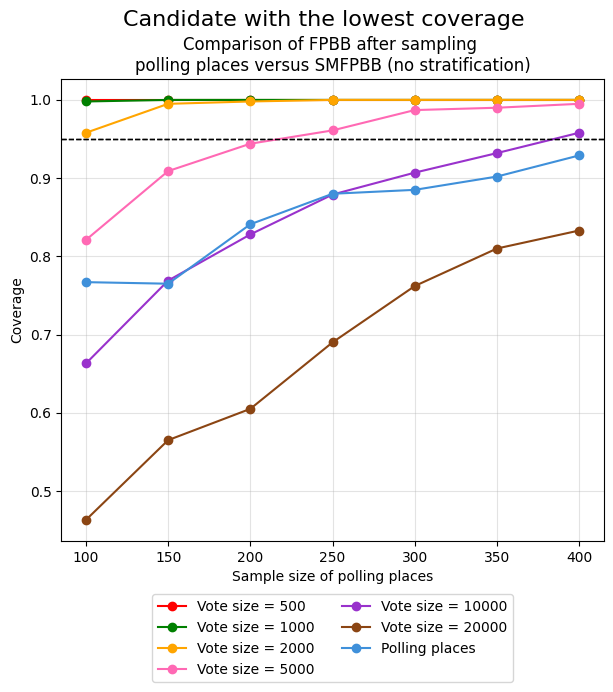

In [19]:
# Tamaño de la gráfica
fig = plt.figure(figsize=(7, 6), dpi=100)
# Para guardar la imagen
#fig = plt.figure(figsize=(7, 6), dpi=300)

# Colores para la gráfica
colors_plot = ["red", "green", "orange", "hotpink", "darkorchid", "saddlebrown", "mediumturquoise"]
plt.axhline(y=0.95, linewidth=1, color='black', ls='--');
l=0
# Para graficar todos las rectas de los votos
for ind_j, j in enumerate(df_boostraps_votos_se["Tamaño_submuestra_votos"].unique()):     
        plt.plot(df_boostraps_votos_se[(df_boostraps_votos_se["Tamaño_submuestra_votos"] == j)]["Tamaño_muestra_casillas"], 
                 df_boostraps_votos_se[(df_boostraps_votos_se["Tamaño_submuestra_votos"] == j)]["Cobertura_m_candidato"],
                 color=colors_plot[ind_j], label=f'Vote size = {j}', linestyle='solid',  marker='o')
        
# La gráfica de las casillas
plt.plot(df_boostraps_c_s_e["Tamaño_muestra_casillas"], df_boostraps_c_s_e["Cobertura_m_candidato"], color='C0', marker='o', label='Polling places')

plt.suptitle('Candidate with the lowest coverage', fontsize=16, y=0.995)
plt.title('Comparison of FPBB after sampling \npolling places versus SMFPBB (no stratification)');
plt.ylabel(ylabel='Coverage');
plt.xlabel('Sample size of polling places')

# Cambiamos el nombre de la leyenda
plt.grid(alpha=0.35);
plt.axhline(y=0.95, linewidth=1, color='black', ls='--');


# Juntamos los títulos y las leyendas con un nombre
plt.legend( bbox_to_anchor=(0.5, -0.1), loc="upper center", shadow=False, ncol=2);

plt.savefig(r"/Users/damian/Documents/Tesis maestria/Imagenes/Casillas_vs_casillas_sub_votos_m_2/No estratificado/Peor_cob_casillas_sub_votos_vs_casillas_m_2.png", bbox_inches='tight',dpi=300);

### Gráficas de las coberturas por candidato

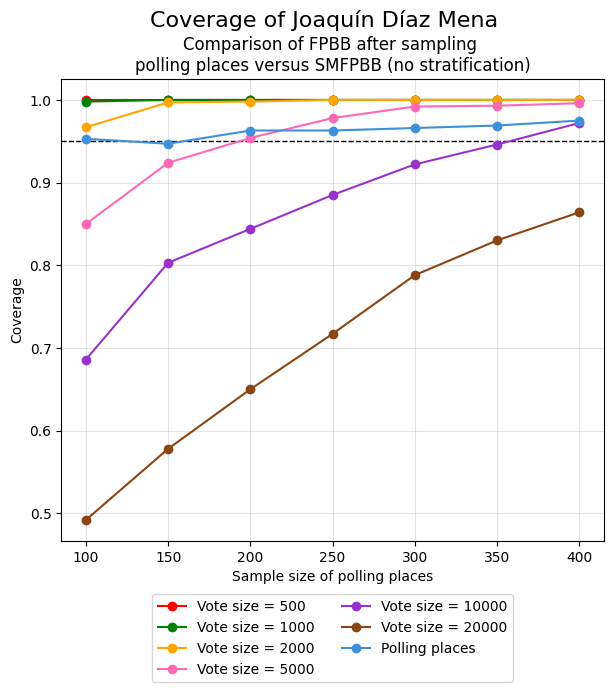

In [21]:
# Tamaño de la gráfica
fig = plt.figure(figsize=(7, 6), dpi=100)

# Para guardar la imagen
#fig = plt.figure(figsize=(7, 6), dpi=300)

# Colores para la gráfica
colors_plot = ["red", "green", "orange", "hotpink", "darkorchid", "saddlebrown", "mediumturquoise"]
plt.axhline(y=0.95, linewidth=1, color='black', ls='--');
l=0
# Para graficar todos las rectas de los votos
for ind_j, j in enumerate(df_boostraps_votos_se["Tamaño_submuestra_votos"].unique()):     
        plt.plot(df_boostraps_votos_se[(df_boostraps_votos_se["Tamaño_submuestra_votos"] == j)]["Tamaño_muestra_casillas"], 
                 df_boostraps_votos_se[(df_boostraps_votos_se["Tamaño_submuestra_votos"] == j)]["Cob_JOAQUIN_DIAZ_MENA"],
                 color=colors_plot[ind_j], label=f'Vote size = {j}', linestyle='solid',  marker='o')
        
# La gráfica de las casillas
plt.plot(df_boostraps_c_s_e["Tamaño_muestra_casillas"], df_boostraps_c_s_e["Cob_JOAQUIN_DIAZ_MENA"], color='C0', marker='o', label='Polling places')

plt.suptitle('Coverage of Joaquín Díaz Mena', fontsize=16, y=0.995)
plt.title('Comparison of FPBB after sampling \npolling places versus SMFPBB (no stratification)');
plt.ylabel(ylabel='Coverage');
plt.xlabel('Sample size of polling places')

# Juntamos los títulos y las leyendas con un nombre
plt.legend(bbox_to_anchor=(0.5, -0.1), loc="upper center", shadow=False, ncol=2);

plt.grid(alpha=0.35);

plt.savefig(r"/Users/damian/Documents/Tesis maestria/Imagenes/Casillas_vs_casillas_sub_votos_m_2/No estratificado/Joaquin_Diaz_Mena_casillas_sub_votos_vs_casillas_m_2_no_est.png", bbox_inches='tight',dpi=300);

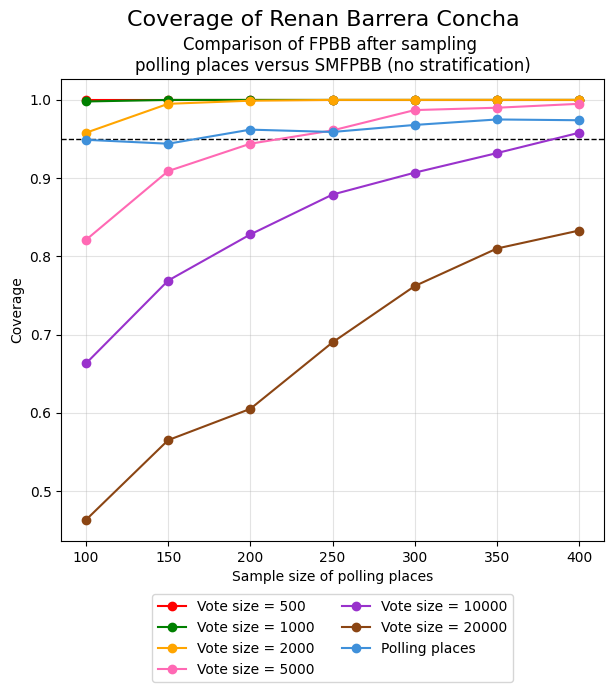

In [22]:
# Tamaño de la gráfica
fig = plt.figure(figsize=(7, 6), dpi=100)

# Para guardar la imagen
#fig = plt.figure(figsize=(7, 6), dpi=300)

# Colores para la gráfica
colors_plot = ["red", "green", "orange", "hotpink", "darkorchid", "saddlebrown", "mediumturquoise"]
plt.axhline(y=0.95, linewidth=1, color='black', ls='--');
l=0
# Para graficar todos las rectas de los votos
for ind_j, j in enumerate(df_boostraps_votos_se["Tamaño_submuestra_votos"].unique()):     
        plt.plot(df_boostraps_votos_se[(df_boostraps_votos_se["Tamaño_submuestra_votos"] == j)]["Tamaño_muestra_casillas"], 
                 df_boostraps_votos_se[(df_boostraps_votos_se["Tamaño_submuestra_votos"] == j)]["Cob_RENAN_BARRERA_CONCHA"],
                 color=colors_plot[ind_j], label=f'Vote size = {j}', linestyle='solid',  marker='o')
        
# La gráfica de las casillas
plt.plot(df_boostraps_c_s_e["Tamaño_muestra_casillas"], df_boostraps_c_s_e["Cob_RENAN_BARRERA_CONCHA"], color='C0', marker='o', label='Polling places')

plt.suptitle('Coverage of Renan Barrera Concha', fontsize=16, y=0.995)
plt.title('Comparison of FPBB after sampling \npolling places versus SMFPBB (no stratification)');
plt.ylabel(ylabel='Coverage');
plt.xlabel('Sample size of polling places')

# Juntamos los títulos y las leyendas con un nombre
plt.legend(bbox_to_anchor=(0.5, -0.1), loc="upper center", shadow=False, ncol=2);

plt.grid(alpha=0.35);
plt.savefig(r"/Users/damian/Documents/Tesis maestria/Imagenes/Casillas_vs_casillas_sub_votos_m_2/No estratificado/Renan_Barrera_Concha_casillas_sub_votos_vs_casillas_m_2_no_est.png", bbox_inches='tight',dpi=300);

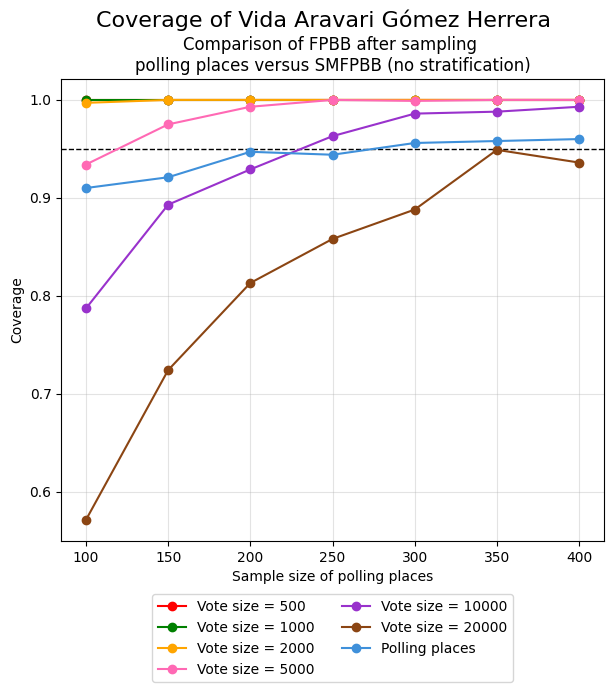

In [25]:
# Tamaño de la gráfica
fig = plt.figure(figsize=(7, 6), dpi=100)

# Guardar la imagen
#fig = plt.figure(figsize=(7, 6), dpi=300)

# Colores para la gráfica
colors_plot = ["red", "green", "orange", "hotpink", "darkorchid", "saddlebrown", "mediumturquoise"]
plt.axhline(y=0.95, linewidth=1, color='black', ls='--');
l=0
# Para graficar todos las rectas de los votos
for ind_j, j in enumerate(df_boostraps_votos_se["Tamaño_submuestra_votos"].unique()):     
        plt.plot(df_boostraps_votos_se[(df_boostraps_votos_se["Tamaño_submuestra_votos"] == j)]["Tamaño_muestra_casillas"], 
                 df_boostraps_votos_se[(df_boostraps_votos_se["Tamaño_submuestra_votos"] == j)]["Cob_VIDA_ARAVARI_GOMEZ_HERRERA"],
                 color=colors_plot[ind_j], label=f'Vote size = {j}', linestyle='solid',  marker='o')
        
# La gráfica de las casillas
plt.plot(df_boostraps_c_s_e["Tamaño_muestra_casillas"], df_boostraps_c_s_e["Cob_VIDA_ARAVARI_GOMEZ_HERRERA"], color='C0', marker='o', label='Polling places')

plt.suptitle('Coverage of Vida Aravari Gómez Herrera', fontsize=16, y=0.995)
plt.title('Comparison of FPBB after sampling \npolling places versus SMFPBB (no stratification)');
plt.ylabel(ylabel='Coverage');
plt.xlabel('Sample size of polling places')

# Juntamos los títulos y las leyendas con un nombre
plt.legend(bbox_to_anchor=(0.5, -0.1), loc="upper center", shadow=False, ncol=2);

plt.grid(alpha=0.35);
plt.savefig(r"/Users/damian/Documents/Tesis maestria/Imagenes/Casillas_vs_casillas_sub_votos_m_2/No estratificado/Vida_Aravari_Gomez_Herrera_casillas_sub_votos_vs_casillas_m_2_no_est.png", bbox_inches='tight',dpi=300);

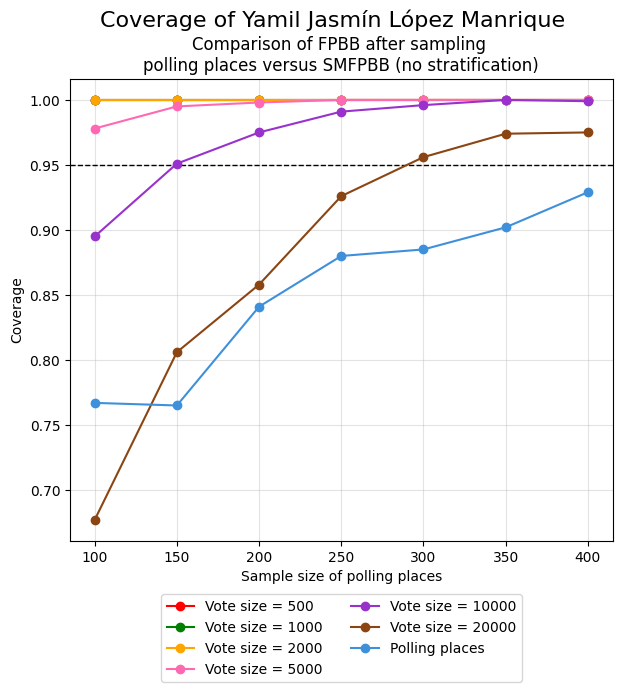

In [27]:
# Tamaño de la gráfica
fig = plt.figure(figsize=(7, 6), dpi=100)

# Guardar la imagen
#fig = plt.figure(figsize=(7, 6), dpi=300)

# Colores para la gráfica
colors_plot = ["red", "green", "orange", "hotpink", "darkorchid", "saddlebrown", "mediumturquoise"]
plt.axhline(y=0.95, linewidth=1, color='black', ls='--');
l=0
# Para graficar todos las rectas de los votos
for ind_j, j in enumerate(df_boostraps_votos_se["Tamaño_submuestra_votos"].unique()):     
        plt.plot(df_boostraps_votos_se[(df_boostraps_votos_se["Tamaño_submuestra_votos"] == j)]["Tamaño_muestra_casillas"], 
                 df_boostraps_votos_se[(df_boostraps_votos_se["Tamaño_submuestra_votos"] == j)]["Cob_YAMIL_JASMIN_LOPEZ_MANRIQUE"],
                 color=colors_plot[ind_j], label=f'Vote size = {j}', linestyle='solid',  marker='o')
        
# La gráfica de las casillas
plt.plot(df_boostraps_c_s_e["Tamaño_muestra_casillas"], df_boostraps_c_s_e["Cob_YAMIL_JASMIN_LOPEZ_MANRIQUE"], color='C0', marker='o', label='Polling places')

plt.suptitle('Coverage of Yamil Jasmín López Manrique', fontsize=16, y=0.995)
plt.title('Comparison of FPBB after sampling \npolling places versus SMFPBB (no stratification)');
plt.ylabel(ylabel='Coverage');
plt.xlabel('Sample size of polling places')

# Juntamos los títulos y las leyendas con un nombre
plt.legend(bbox_to_anchor=(0.5, -0.1), loc="upper center", shadow=False, ncol=2);

plt.grid(alpha=0.35);
plt.savefig(r"/Users/damian/Documents/Tesis maestria/Imagenes/Casillas_vs_casillas_sub_votos_m_2/No estratificado/Jasmin_Lopez_Manrique_casillas_sub_votos_vs_casillas_m_2_no_est.png", bbox_inches='tight',dpi=300);

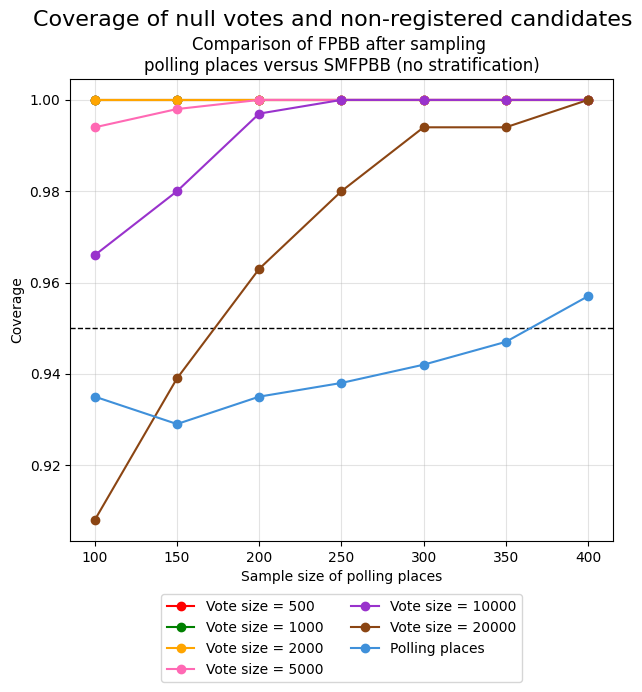

In [30]:
# Tamaño de la gráfica
fig = plt.figure(figsize=(7, 6), dpi=100)

# Guardar la imagen
#fig = plt.figure(figsize=(7, 6), dpi=300)

# Colores para la gráfica
colors_plot = ["red", "green", "orange", "hotpink", "darkorchid", "saddlebrown", "mediumturquoise"]
plt.axhline(y=0.95, linewidth=1, color='black', ls='--');
l=0
# Para graficar todos las rectas de los votos
for ind_j, j in enumerate(df_boostraps_votos_se["Tamaño_submuestra_votos"].unique()):     
        plt.plot(df_boostraps_votos_se[(df_boostraps_votos_se["Tamaño_submuestra_votos"] == j)]["Tamaño_muestra_casillas"], 
                 df_boostraps_votos_se[(df_boostraps_votos_se["Tamaño_submuestra_votos"] == j)]["Cob_VOTOS_NULOS_CAND_NO_REGIS"],
                 color=colors_plot[ind_j], label=f'Vote size = {j}', linestyle='solid',  marker='o')
        
# La gráfica de las casillas
plt.plot(df_boostraps_c_s_e["Tamaño_muestra_casillas"], df_boostraps_c_s_e["Cob_VOTOS_NULOS_CAND_NO_REGIS"], color='C0', marker='o', label='Polling places')

plt.suptitle('Coverage of null votes and non-registered candidates', fontsize=16, y=0.995)
plt.title('Comparison of FPBB after sampling \npolling places versus SMFPBB (no stratification)');
plt.ylabel(ylabel='Coverage');
plt.xlabel('Sample size of polling places')

# Juntamos los títulos y las leyendas con un nombre
plt.legend(bbox_to_anchor=(0.5, -0.1), loc="upper center", shadow=False, ncol=2);

plt.grid(alpha=0.35);
plt.savefig(r"/Users/damian/Documents/Tesis maestria/Imagenes/Casillas_vs_casillas_sub_votos_m_2/No estratificado/Votos_nulos_no_reg_casillas_sub_votos_vs_casillas_m_2_no_est.png", bbox_inches='tight',dpi=300);

## Comparación bootstraps estratificados

In [31]:
# Leemos las bases
# Base de bootstrap por casillas sin estratificar
df_boostraps_c_est=pd.read_csv(r"/Users/damian/Documents/Tesis maestria/Bootstraps_codigos_bases/Bases finales rep/Bootstrap por casillas/Distintas_muestras_casillas_bootstrap_estratificado_f_1.csv", index_col=0)
# Base de bootstrap por votos (submuestreo) método 1
df_boostraps_votos_est=pd.read_csv(r"/Users/damian/Documents/Tesis maestria/Bootstraps_codigos_bases/Bases finales rep/Bootstrap votos/Metodo 2/Distintas_muestras_submuestras_bootstrap_votos_met_2_estratificado_f_1.csv", index_col=0)


## Reducción intervalo más largo

In [32]:
# Por casillas
1-df_boostraps_c_est["Intervalo_M_grande_inter_mediana"].min()/df_boostraps_c_est["Intervalo_M_grande_inter_mediana"].max()

np.float64(0.38188583431632017)

In [33]:
# Por casillas luego votos
a=df_boostraps_votos_est.groupby('Tamaño_submuestra_votos').agg({'Intervalo_M_grande_inter_mediana':['max','min']})
a.columns=a.columns.map('_'.join)
a=a.reset_index()
a["Reduccion"]=1-a["Intervalo_M_grande_inter_mediana_min"]/a["Intervalo_M_grande_inter_mediana_max"]
a

,Tamaño_submuestra_votos,Intervalo_M_grande_inter_mediana_max,Intervalo_M_grande_inter_mediana_min,Reduccion
0,500,0.119008,0.118423,0.004911
1,1000,0.085076,0.084238,0.009849
2,2000,0.060451,0.059617,0.013806
3,5000,0.038239,0.037322,0.023979
4,10000,0.027076,0.025714,0.050313
5,20000,0.020272,0.019587,0.033806


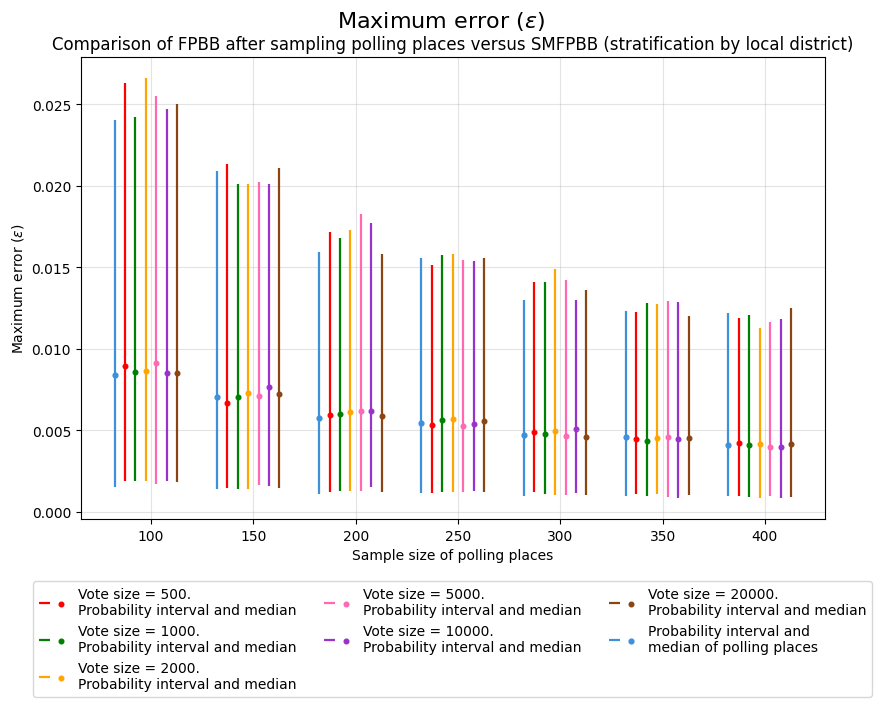

In [35]:
# Tamaño de la gráfica
fig = plt.figure(figsize=(9.6, 6), dpi=100)
# Para guardar la imagen
#fig = plt.figure(figsize=(9.6, 6), dpi=350)
ax = fig.add_subplot(111)

# Colores para la gráfica
colors_plot = ["red", "green", "orange", "hotpink", "darkorchid", "saddlebrown", "mediumturquoise"]

# Lista de los labels de las gráficas
labels_votos = []

# Lista para guardar las gráficas
lista_graficas = []

# Para que no se crucen las líneas
offset = 5.1

# Primero hacemos un for para crear los valores para que no crucen las líneas
valores_x_grafica=[]
for ind_j, j in enumerate(df_boostraps_votos_est["Tamaño_submuestra_votos"].unique()):
    k = 0
    for ind_i, i in enumerate(df_boostraps_votos_est["Tamaño_muestra_casillas"].unique()):

        # Slightly offset the x position for each subcategory
        valores_x_grafica.append( i + (ind_j - (len(df_boostraps_votos_est["Tamaño_submuestra_votos"].unique())+1) / 2) * offset)


# Para graficar todos las rectas de los votos
for ind_j, j in enumerate(df_boostraps_votos_est["Tamaño_submuestra_votos"].unique()):
    l=0
    for ind_i, i in enumerate(df_boostraps_votos_est["Tamaño_muestra_casillas"].unique()):
              
        if l==0:
            # Slightly offset the x position for each subcategory
            x_position = i + (ind_j+1 - (len(df_boostraps_votos_est["Tamaño_submuestra_votos"].unique())+1) / 2) * offset

            # Guardamos en lista los labels
            labels_votos.append(f"Vote size = {j}. \nProbability interval and median")
            linea_1=ax.vlines(
                x_position,
                df_boostraps_votos_est[
                    (df_boostraps_votos_est["Tamaño_muestra_casillas"] == i)
                    & (df_boostraps_votos_est["Tamaño_submuestra_votos"] == j)
                ]["Error_maximo_q_025"].iloc[0],
                df_boostraps_votos_est[
                    (df_boostraps_votos_est["Tamaño_muestra_casillas"] == i)
                    & (df_boostraps_votos_est["Tamaño_submuestra_votos"] == j)
                ]["Error_maximo_q_975"].iloc[0],
                color=colors_plot[ind_j],
                linestyle="solid",
                label=f"Muestra votos = {j} (sin estratificar)",
                linewidth=1.6
            )
            punto_1=plt.scatter(x_position, df_boostraps_votos_est[
                    (df_boostraps_votos_est["Tamaño_muestra_casillas"] == i)
                    & (df_boostraps_votos_est["Tamaño_submuestra_votos"] == j)
                ]["Error_maximo_mediana"].iloc[0], color=colors_plot[ind_j], s=11)
            
            # Para que aparezcan los nombres
            lista_graficas.append((linea_1, punto_1))


        else:
            # Slightly offset the x position for each subcategory
            x_position = i + (ind_j+1 - (len(df_boostraps_votos_est["Tamaño_submuestra_votos"].unique())+1) / 2) * offset

            # Guardamos en lista los labels
            #labels_votos.append(f"Sample size of votes = {j}. \nProbability interval and median")
            ax.vlines(
                x_position,
                df_boostraps_votos_est[
                    (df_boostraps_votos_est["Tamaño_muestra_casillas"] == i)
                    & (df_boostraps_votos_est["Tamaño_submuestra_votos"] == j)
                ]["Error_maximo_q_025"].iloc[0],
                df_boostraps_votos_est[
                    (df_boostraps_votos_est["Tamaño_muestra_casillas"] == i)
                    & (df_boostraps_votos_est["Tamaño_submuestra_votos"] == j)
                ]["Error_maximo_q_975"].iloc[0],
                color=colors_plot[ind_j],
                linestyle="solid",
                linewidth=1.6
            )
            plt.scatter(x_position, df_boostraps_votos_est[
            (df_boostraps_votos_est["Tamaño_muestra_casillas"] == i)
            & (df_boostraps_votos_est["Tamaño_submuestra_votos"] == j)
        ]["Error_maximo_mediana"].iloc[0], color=colors_plot[ind_j], s=11)
            
        l=l+1


k=0

# Las gráficas de los intervalos de probabilidad de las casillas
for ind_i, i in enumerate(df_boostraps_c_est["Tamaño_muestra_casillas"].unique()):

    if k==0:
        x_position = valores_x_grafica[ind_i]
        # Guardamos en lista los labels
        labels_votos.append(f"Probability interval and \nmedian of polling places")
        linea_2=ax.vlines(
            x_position,
            df_boostraps_c_est[
                (df_boostraps_c_est["Tamaño_muestra_casillas"] == i)
            ]["Error_maximo_q_025"].iloc[0],
            df_boostraps_c_est[
                (df_boostraps_c_est["Tamaño_muestra_casillas"] == i)
            ]["Error_maximo_q_975"].iloc[0],
            linestyle="solid",
            label=f"Polling places",
            linewidth=1.6
        )
        # Graficamos las medianas
        punto_2=ax.scatter(x_position,df_boostraps_c_est[(df_boostraps_c_est["Tamaño_muestra_casillas"]==i)]["Error_maximo_mediana"].iloc[0], color='C0', s=12)
        # Para que aparezcan los nombres
        lista_graficas.append((linea_2, punto_2))
    else:
        x_position = valores_x_grafica[ind_i]
        # Guardamos en lista los labels
        #labels_votos.append(f"Probability interval of \npolling places")
        ax.vlines(
            x_position,
            df_boostraps_c_est[
                (df_boostraps_c_est["Tamaño_muestra_casillas"] == i)
            ]["Error_maximo_q_025"].iloc[0],
            df_boostraps_c_est[
                (df_boostraps_c_est["Tamaño_muestra_casillas"] == i)
            ]["Error_maximo_q_975"].iloc[0],
            linestyle="solid",
            linewidth=1.6
        )
        # Graficamos las medianas
        ax.scatter(x_position,df_boostraps_c_est[(df_boostraps_c_est["Tamaño_muestra_casillas"]==i)]["Error_maximo_mediana"].iloc[0], color='C0', s=12)
    k=l+1


# Juntamos los títulos y las leyendas con un nombre
plt.legend(bbox_to_anchor=(0.5, -0.12), ncol=2, loc="upper center", numpoints=1)

lgnd = ax.legend(lista_graficas, labels_votos, bbox_to_anchor=(0.5, -0.12), ncol=3, loc="upper center", numpoints=1, handler_map = {tuple: legend_handler.HandlerTuple(None)})

plt.suptitle("Maximum error ($\\epsilon$)", fontsize=16, y=0.96)
plt.title("Comparison of FPBB after sampling polling places versus SMFPBB (stratification by local district)")

plt.xlabel("Sample size of polling places")
plt.ylabel("Maximum error ($\\epsilon$)")

plt.grid(alpha=0.35);
plt.savefig(r"/Users/damian/Documents/Tesis maestria/Imagenes/Casillas_vs_casillas_sub_votos_m_2/Estratificado/Error_casillas_sub_votos_vs_casillas_m_2_est.png", bbox_inches='tight',dpi=300);

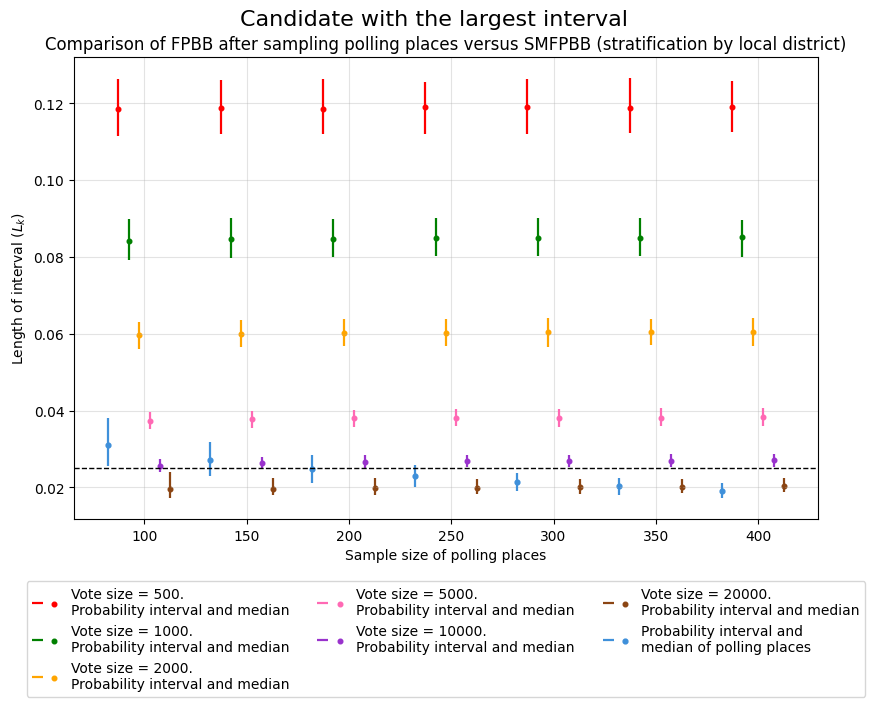

In [37]:
# Tamaño de la gráfica
fig = plt.figure(figsize=(9.6, 6), dpi=100)
# Para guardar la imagen
#fig = plt.figure(figsize=(9.6, 6), dpi=350)
ax = fig.add_subplot(111)

# Colores para la gráfica
colors_plot = ["red", "green", "orange", "hotpink", "darkorchid", "saddlebrown", "mediumturquoise"]

# Lista de los labels de las gráficas
labels_votos = []

# Lista para guardar las gráficas
lista_graficas = []

# Para que no se crucen las líneas
offset = 5.1

# Primero hacemos un for para crear los valores para que no crucen las líneas
valores_x_grafica=[]
for ind_j, j in enumerate(df_boostraps_votos_est["Tamaño_submuestra_votos"].unique()):
    k = 0
    for ind_i, i in enumerate(df_boostraps_votos_est["Tamaño_muestra_casillas"].unique()):

        # Slightly offset the x position for each subcategory
        valores_x_grafica.append( i + (ind_j - (len(df_boostraps_votos_est["Tamaño_submuestra_votos"].unique())+1) / 2) * offset)


# Para graficar todos las rectas de los votos
for ind_j, j in enumerate(df_boostraps_votos_est["Tamaño_submuestra_votos"].unique()):
    l=0
    for ind_i, i in enumerate(df_boostraps_votos_est["Tamaño_muestra_casillas"].unique()):
              
        if l==0:
            # Slightly offset the x position for each subcategory
            x_position = i + (ind_j+1 - (len(df_boostraps_votos_est["Tamaño_submuestra_votos"].unique())+1) / 2) * offset

            # Guardamos en lista los labels
            labels_votos.append(f"Vote size = {j}. \nProbability interval and median")
            linea_1=ax.vlines(
                x_position,
                df_boostraps_votos_est[
                    (df_boostraps_votos_est["Tamaño_muestra_casillas"] == i)
                    & (df_boostraps_votos_est["Tamaño_submuestra_votos"] == j)
                ]["Intervalo_M_grande_inter_q_025"].iloc[0],
                df_boostraps_votos_est[
                    (df_boostraps_votos_est["Tamaño_muestra_casillas"] == i)
                    & (df_boostraps_votos_est["Tamaño_submuestra_votos"] == j)
                ]["Intervalo_M_grande_inter_q_975"].iloc[0],
                color=colors_plot[ind_j],
                linestyle="solid",
                label=f"Muestra votos = {j} (sin estratificar)",
                linewidth=1.6
            )
            punto_1=plt.scatter(x_position, df_boostraps_votos_est[
                    (df_boostraps_votos_est["Tamaño_muestra_casillas"] == i)
                    & (df_boostraps_votos_est["Tamaño_submuestra_votos"] == j)
                ]["Intervalo_M_grande_inter_mediana"].iloc[0], color=colors_plot[ind_j], s=11)
            
            # Para que aparezcan los nombres
            lista_graficas.append((linea_1, punto_1))


        else:
            # Slightly offset the x position for each subcategory
            x_position = i + (ind_j+1 - (len(df_boostraps_votos_est["Tamaño_submuestra_votos"].unique())+1) / 2) * offset

            # Guardamos en lista los labels
            #labels_votos.append(f"Sample size of votes = {j}. \nProbability interval and median")
            ax.vlines(
                x_position,
                df_boostraps_votos_est[
                    (df_boostraps_votos_est["Tamaño_muestra_casillas"] == i)
                    & (df_boostraps_votos_est["Tamaño_submuestra_votos"] == j)
                ]["Intervalo_M_grande_inter_q_025"].iloc[0],
                df_boostraps_votos_est[
                    (df_boostraps_votos_est["Tamaño_muestra_casillas"] == i)
                    & (df_boostraps_votos_est["Tamaño_submuestra_votos"] == j)
                ]["Intervalo_M_grande_inter_q_975"].iloc[0],
                color=colors_plot[ind_j],
                linestyle="solid",
                linewidth=1.6
            )
            plt.scatter(x_position, df_boostraps_votos_est[
            (df_boostraps_votos_est["Tamaño_muestra_casillas"] == i)
            & (df_boostraps_votos_est["Tamaño_submuestra_votos"] == j)
        ]["Intervalo_M_grande_inter_mediana"].iloc[0], color=colors_plot[ind_j], s=11)
            
        l=l+1


k=0

# Las gráficas de los intervalos de probabilidad de las casillas
for ind_i, i in enumerate(df_boostraps_c_est["Tamaño_muestra_casillas"].unique()):

    if k==0:
        x_position = valores_x_grafica[ind_i]
        # Guardamos en lista los labels
        labels_votos.append(f"Probability interval and \nmedian of polling places")
        linea_2=ax.vlines(
            x_position,
            df_boostraps_c_est[
                (df_boostraps_c_est["Tamaño_muestra_casillas"] == i)
            ]["Intervalo_M_grande_inter_q_025"].iloc[0],
            df_boostraps_c_est[
                (df_boostraps_c_est["Tamaño_muestra_casillas"] == i)
            ]["Intervalo_M_grande_inter_q_975"].iloc[0],
            linestyle="solid",
            label=f"Polling places",
            linewidth=1.6
        )
        # Graficamos las medianas
        punto_2=ax.scatter(x_position,df_boostraps_c_est[(df_boostraps_c_est["Tamaño_muestra_casillas"]==i)]["Intervalo_M_grande_inter_mediana"].iloc[0], color='C0', s=12)
        # Para que aparezcan los nombres
        lista_graficas.append((linea_2, punto_2))
    else:
        x_position = valores_x_grafica[ind_i]
        # Guardamos en lista los labels
        #labels_votos.append(f"Probability interval of \npolling places")
        ax.vlines(
            x_position,
            df_boostraps_c_est[
                (df_boostraps_c_est["Tamaño_muestra_casillas"] == i)
            ]["Intervalo_M_grande_inter_q_025"].iloc[0],
            df_boostraps_c_est[
                (df_boostraps_c_est["Tamaño_muestra_casillas"] == i)
            ]["Intervalo_M_grande_inter_q_975"].iloc[0],
            linestyle="solid",
            linewidth=1.6
        )
        # Graficamos las medianas
        ax.scatter(x_position,df_boostraps_c_est[(df_boostraps_c_est["Tamaño_muestra_casillas"]==i)]["Intervalo_M_grande_inter_mediana"].iloc[0], color='C0', s=12)
    k=l+1


# Juntamos los títulos y las leyendas con un nombre
plt.legend(bbox_to_anchor=(0.5, -0.12), ncol=2, loc="upper center", numpoints=1)

lgnd = ax.legend(lista_graficas, labels_votos, bbox_to_anchor=(0.5, -0.12), ncol=3, loc="upper center", numpoints=1, handler_map = {tuple: legend_handler.HandlerTuple(None)})

plt.suptitle('Candidate with the largest interval', fontsize=16, y=0.96)
plt.title("Comparison of FPBB after sampling polling places versus SMFPBB (stratification by local district)")
plt.axhline(y=0.025, linewidth=1, color='black', ls='--');

plt.xlabel('Sample size of polling places')
plt.ylabel('Length of interval ($L_{k}$)');
plt.grid(alpha=0.35);
plt.savefig(r"/Users/damian/Documents/Tesis maestria/Imagenes/Casillas_vs_casillas_sub_votos_m_2/Estratificado/Intervalo_mas_largo_casillas_sub_votos_vs_casillas_m_2_est.png", bbox_inches='tight',dpi=300);

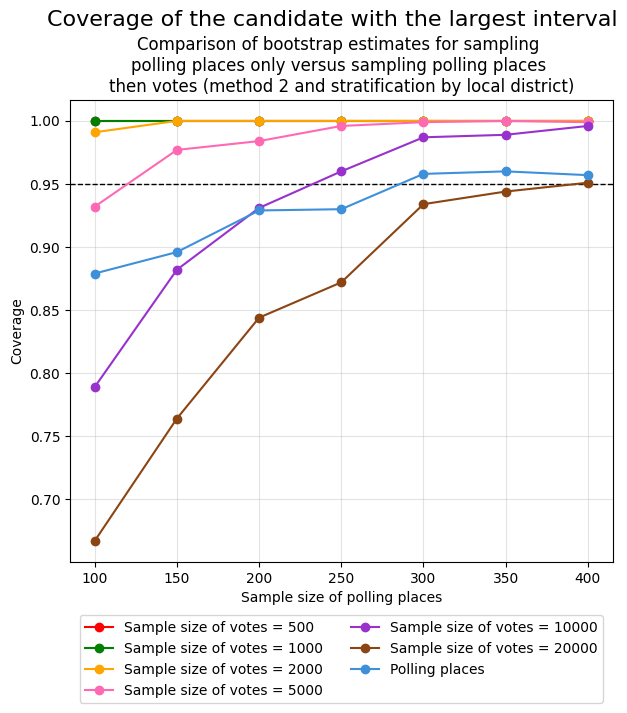

In [10]:
# Tamaño de la gráfica
fig = plt.figure(figsize=(7, 6), dpi=100)
# Para guardar la imagen
#fig = plt.figure(figsize=(7, 6), dpi=300)

# Colores para la gráfica
colors_plot = ["red", "green", "orange", "hotpink", "darkorchid", "saddlebrown", "mediumturquoise"]
plt.axhline(y=0.95, linewidth=1, color='black', ls='--');
l=0
# Para graficar todos las rectas de los votos
for ind_j, j in enumerate(df_boostraps_votos_est["Tamaño_submuestra_votos"].unique()):     
        plt.plot(df_boostraps_votos_est[(df_boostraps_votos_est["Tamaño_submuestra_votos"] == j)]["Tamaño_muestra_casillas"], 
                 df_boostraps_votos_est[(df_boostraps_votos_est["Tamaño_submuestra_votos"] == j)]["Intervalo_M_grande_candidato_cob"],
                 color=colors_plot[ind_j], label=f'Sample size of votes = {j}', linestyle='solid',  marker='o')
        
# La gráfica de las casillas
plt.plot(df_boostraps_c_est["Tamaño_muestra_casillas"], df_boostraps_c_est["Intervalo_M_grande_candidato_cob"], color='C0', marker='o', label='Polling places')

plt.suptitle('Coverage of the candidate with the largest interval', fontsize=16, y=1.03)
plt.title('Comparison of bootstrap estimates for sampling \npolling places only versus sampling polling places \nthen votes (method 2 and stratification by local district)');
plt.ylabel(ylabel='Coverage');
plt.xlabel('Sample size of polling places')

# Cambiamos el nombre de la leyenda
plt.grid(alpha=0.35);


# Juntamos los títulos y las leyendas con un nombre
plt.legend( bbox_to_anchor=(0.5, -0.1), loc="upper center", shadow=False, ncol=2);

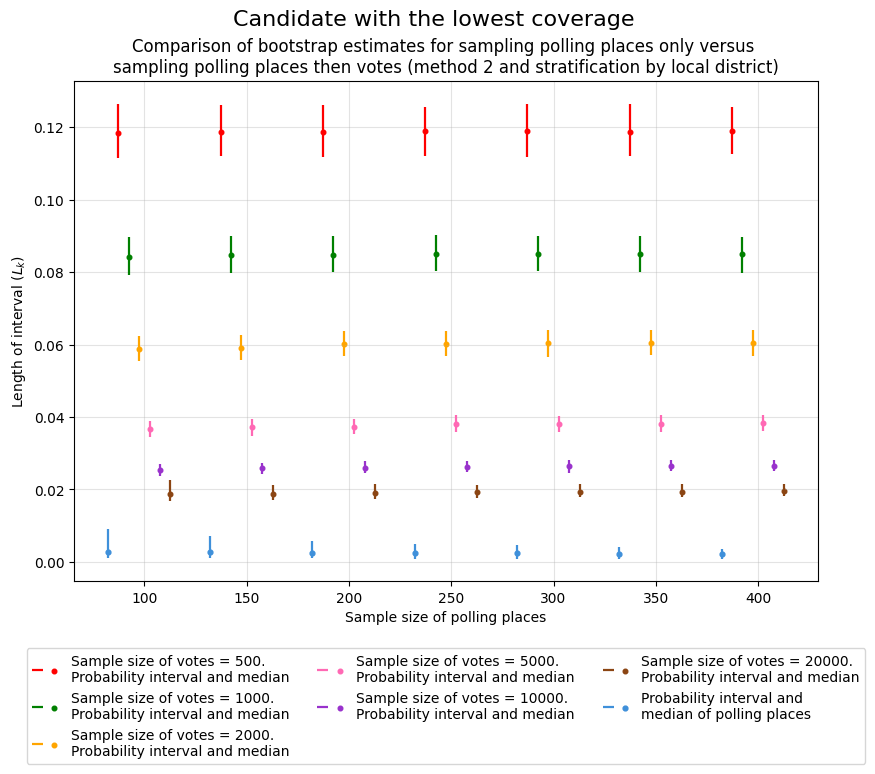

In [11]:
# Tamaño de la gráfica
fig = plt.figure(figsize=(9.6, 6.5), dpi=100)
ax = fig.add_subplot(111)

# Colores para la gráfica
colors_plot = ["red", "green", "orange", "hotpink", "darkorchid", "saddlebrown", "mediumturquoise"]

# Lista de los labels de las gráficas
labels_votos = []

# Lista para guardar las gráficas
lista_graficas = []

# Para que no se crucen las líneas
offset = 5.1

# Primero hacemos un for para crear los valores para que no crucen las líneas
valores_x_grafica=[]
for ind_j, j in enumerate(df_boostraps_votos_est["Tamaño_submuestra_votos"].unique()):
    k = 0
    for ind_i, i in enumerate(df_boostraps_votos_est["Tamaño_muestra_casillas"].unique()):

        # Slightly offset the x position for each subcategory
        valores_x_grafica.append( i + (ind_j - (len(df_boostraps_votos_est["Tamaño_submuestra_votos"].unique())+1) / 2) * offset)


# Para graficar todos las rectas de los votos
for ind_j, j in enumerate(df_boostraps_votos_est["Tamaño_submuestra_votos"].unique()):
    l=0
    for ind_i, i in enumerate(df_boostraps_votos_est["Tamaño_muestra_casillas"].unique()):
              
        if l==0:
            # Slightly offset the x position for each subcategory
            x_position = i + (ind_j+1 - (len(df_boostraps_votos_est["Tamaño_submuestra_votos"].unique())+1) / 2) * offset

            # Guardamos en lista los labels
            labels_votos.append(f"Sample size of votes = {j}. \nProbability interval and median")
            linea_1=ax.vlines(
                x_position,
                df_boostraps_votos_est[
                    (df_boostraps_votos_est["Tamaño_muestra_casillas"] == i)
                    & (df_boostraps_votos_est["Tamaño_submuestra_votos"] == j)
                ]["Cobertura_m_inter_q_025"].iloc[0],
                df_boostraps_votos_est[
                    (df_boostraps_votos_est["Tamaño_muestra_casillas"] == i)
                    & (df_boostraps_votos_est["Tamaño_submuestra_votos"] == j)
                ]["Cobertura_m_inter_q_975"].iloc[0],
                color=colors_plot[ind_j],
                linestyle="solid",
                label=f"Muestra votos = {j} (sin estratificar)",
                linewidth=1.6
            )
            punto_1=plt.scatter(x_position, df_boostraps_votos_est[
                    (df_boostraps_votos_est["Tamaño_muestra_casillas"] == i)
                    & (df_boostraps_votos_est["Tamaño_submuestra_votos"] == j)
                ]["Cobertura_m_inter_mediana"].iloc[0], color=colors_plot[ind_j], s=11)
            
            # Para que aparezcan los nombres
            lista_graficas.append((linea_1, punto_1))

        else:
            # Slightly offset the x position for each subcategory
            x_position = i + (ind_j+1 - (len(df_boostraps_votos_est["Tamaño_submuestra_votos"].unique())+1) / 2) * offset

            # Guardamos en lista los labels
            #labels_votos.append(f"Sample size of votes = {j}. \nProbability interval and median")
            ax.vlines(
                x_position,
                df_boostraps_votos_est[
                    (df_boostraps_votos_est["Tamaño_muestra_casillas"] == i)
                    & (df_boostraps_votos_est["Tamaño_submuestra_votos"] == j)
                ]["Cobertura_m_inter_q_025"].iloc[0],
                df_boostraps_votos_est[
                    (df_boostraps_votos_est["Tamaño_muestra_casillas"] == i)
                    & (df_boostraps_votos_est["Tamaño_submuestra_votos"] == j)
                ]["Cobertura_m_inter_q_975"].iloc[0],
                color=colors_plot[ind_j],
                linestyle="solid",
                linewidth=1.6
            )
            plt.scatter(x_position, df_boostraps_votos_est[
            (df_boostraps_votos_est["Tamaño_muestra_casillas"] == i)
            & (df_boostraps_votos_est["Tamaño_submuestra_votos"] == j)
        ]["Cobertura_m_inter_mediana"].iloc[0], color=colors_plot[ind_j], s=11)
            
        l=l+1


k=0

# Las gráficas de los intervalos de probabilidad de las casillas
for ind_i, i in enumerate(df_boostraps_c_est["Tamaño_muestra_casillas"].unique()):

    if k==0:
        x_position = valores_x_grafica[ind_i]
        # Guardamos en lista los labels
        labels_votos.append(f"Probability interval and \nmedian of polling places")
        linea_2=ax.vlines(
            x_position,
            df_boostraps_c_est[
                (df_boostraps_c_est["Tamaño_muestra_casillas"] == i)
            ]["Cobertura_m_inter_q_025"].iloc[0],
            df_boostraps_c_est[
                (df_boostraps_c_est["Tamaño_muestra_casillas"] == i)
            ]["Cobertura_m_inter_q_975"].iloc[0],
            linestyle="solid",
            label=f"Polling places",
            linewidth=1.6
        )
        # Graficamos las medianas
        punto_2=ax.scatter(x_position,df_boostraps_c_est[(df_boostraps_c_est["Tamaño_muestra_casillas"]==i)]["Cobertura_m_inter_mediana"].iloc[0], color='C0', s=12)
        # Para que aparezcan los nombres
        lista_graficas.append((linea_2, punto_2))
    else:
        x_position = valores_x_grafica[ind_i]
        # Guardamos en lista los labels
        #labels_votos.append(f"Probability interval of \npolling places")
        ax.vlines(
            x_position,
            df_boostraps_c_est[
                (df_boostraps_c_est["Tamaño_muestra_casillas"] == i)
            ]["Cobertura_m_inter_q_025"].iloc[0],
            df_boostraps_c_est[
                (df_boostraps_c_est["Tamaño_muestra_casillas"] == i)
            ]["Cobertura_m_inter_q_975"].iloc[0],
            linestyle="solid",
            linewidth=1.6
        )
        # Graficamos las medianas
        ax.scatter(x_position,df_boostraps_c_est[(df_boostraps_c_est["Tamaño_muestra_casillas"]==i)]["Cobertura_m_inter_mediana"].iloc[0], color='C0', s=12)
    k=l+1


# Juntamos los títulos y las leyendas con un nombre
plt.legend(bbox_to_anchor=(0.5, -0.12), ncol=2, loc="upper center", numpoints=1)

lgnd = ax.legend(lista_graficas, labels_votos, bbox_to_anchor=(0.5, -0.12), ncol=3, loc="upper center", numpoints=1, handler_map = {tuple: legend_handler.HandlerTuple(None)})

plt.suptitle('Candidate with the lowest coverage', fontsize=16, y=0.99)
plt.title("Comparison of bootstrap estimates for sampling polling places only versus \nsampling polling places then votes (method 2 and stratification by local district)")

plt.xlabel('Sample size of polling places')
plt.ylabel('Length of interval ($L_{k}$)');
plt.grid(alpha=0.35);

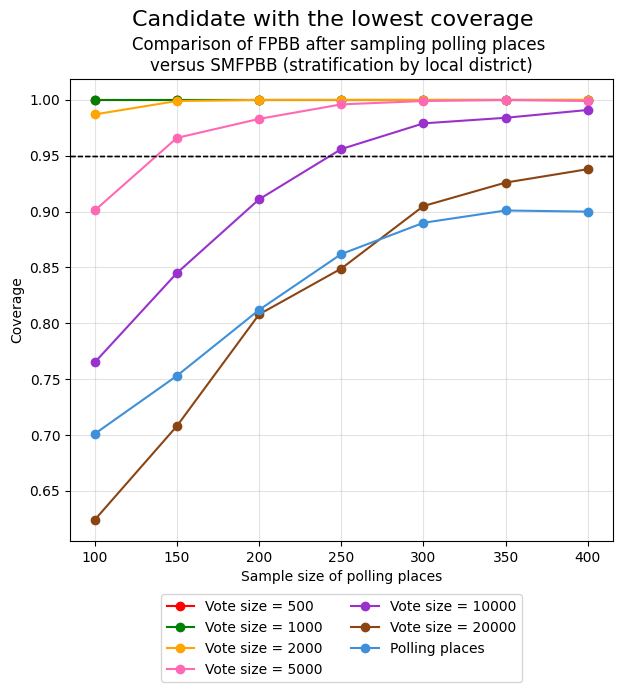

In [39]:
# Tamaño de la gráfica
fig = plt.figure(figsize=(7, 6), dpi=100)
# Para guardar la imagen
#fig = plt.figure(figsize=(7, 6), dpi=300)

# Colores para la gráfica
colors_plot = ["red", "green", "orange", "hotpink", "darkorchid", "saddlebrown", "mediumturquoise"]
plt.axhline(y=0.95, linewidth=1, color='black', ls='--');
l=0
# Para graficar todos las rectas de los votos
for ind_j, j in enumerate(df_boostraps_votos_est["Tamaño_submuestra_votos"].unique()):     
        plt.plot(df_boostraps_votos_est[(df_boostraps_votos_est["Tamaño_submuestra_votos"] == j)]["Tamaño_muestra_casillas"], 
                 df_boostraps_votos_est[(df_boostraps_votos_est["Tamaño_submuestra_votos"] == j)]["Cobertura_m_candidato"],
                 color=colors_plot[ind_j], label=f'Vote size = {j}', linestyle='solid',  marker='o')
        
# La gráfica de las casillas
plt.plot(df_boostraps_c_est["Tamaño_muestra_casillas"], df_boostraps_c_est["Cobertura_m_candidato"], color='C0', marker='o', label='Polling places')

plt.suptitle('Candidate with the lowest coverage', fontsize=16, y=0.995)
plt.title('Comparison of FPBB after sampling polling places \nversus SMFPBB (stratification by local district)');
plt.ylabel(ylabel='Coverage');
plt.xlabel('Sample size of polling places')

# Cambiamos el nombre de la leyenda
plt.grid(alpha=0.35);
plt.axhline(y=0.95, linewidth=1, color='black', ls='--');


# Juntamos los títulos y las leyendas con un nombre
plt.legend( bbox_to_anchor=(0.5, -0.1), loc="upper center", shadow=False, ncol=2);
plt.savefig(r"/Users/damian/Documents/Tesis maestria/Imagenes/Casillas_vs_casillas_sub_votos_m_2/Estratificado/Peor_cob_casillas_sub_votos_vs_casillas_m_2_est.png", bbox_inches='tight',dpi=300);

### Gráficas de las coberturas por candidato

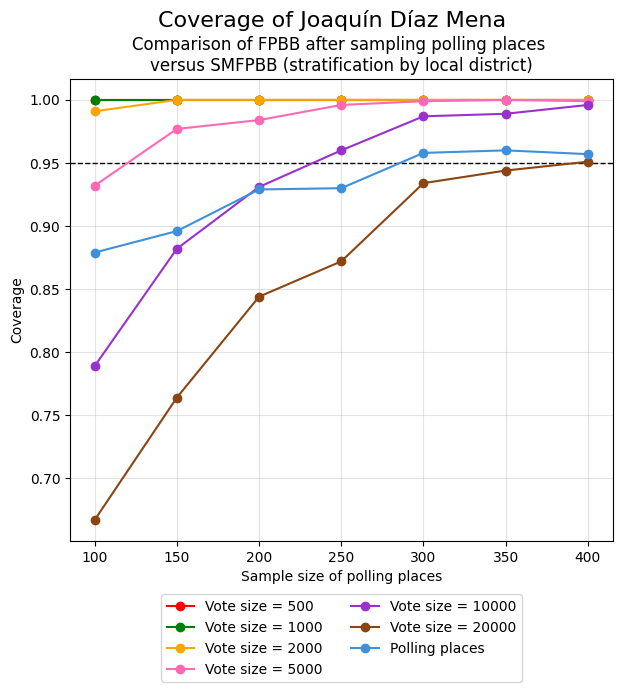

In [41]:
# Tamaño de la gráfica
fig = plt.figure(figsize=(7, 6), dpi=100)
# Para guardar la gráfica
#fig = plt.figure(figsize=(7, 6), dpi=300)

# Colores para la gráfica
colors_plot = ["red", "green", "orange", "hotpink", "darkorchid", "saddlebrown", "mediumturquoise"]
plt.axhline(y=0.95, linewidth=1, color='black', ls='--');
l=0
# Para graficar todos las rectas de los votos
for ind_j, j in enumerate(df_boostraps_votos_est["Tamaño_submuestra_votos"].unique()):     
        plt.plot(df_boostraps_votos_est[(df_boostraps_votos_est["Tamaño_submuestra_votos"] == j)]["Tamaño_muestra_casillas"], 
                 df_boostraps_votos_est[(df_boostraps_votos_est["Tamaño_submuestra_votos"] == j)]["Cob_JOAQUIN_DIAZ_MENA"],
                 color=colors_plot[ind_j], label=f'Vote size = {j}', linestyle='solid',  marker='o')
        
# La gráfica de las casillas
plt.plot(df_boostraps_c_est["Tamaño_muestra_casillas"], df_boostraps_c_est["Cob_JOAQUIN_DIAZ_MENA"], color='C0', marker='o', label='Polling places')

plt.suptitle('Coverage of Joaquín Díaz Mena', fontsize=16, y=0.995)
plt.title('Comparison of FPBB after sampling polling places \nversus SMFPBB (stratification by local district)');
plt.ylabel(ylabel='Coverage');
plt.xlabel('Sample size of polling places')

# Juntamos los títulos y las leyendas con un nombre
plt.legend(bbox_to_anchor=(0.5, -0.1), loc="upper center", shadow=False, ncol=2);

plt.grid(alpha=0.35);
plt.savefig(r"/Users/damian/Documents/Tesis maestria/Imagenes/Casillas_vs_casillas_sub_votos_m_2/Estratificado/Joaquin_Diaz_Mena_casillas_sub_votos_vs_casillas_m_2_est.png", bbox_inches='tight',dpi=300);

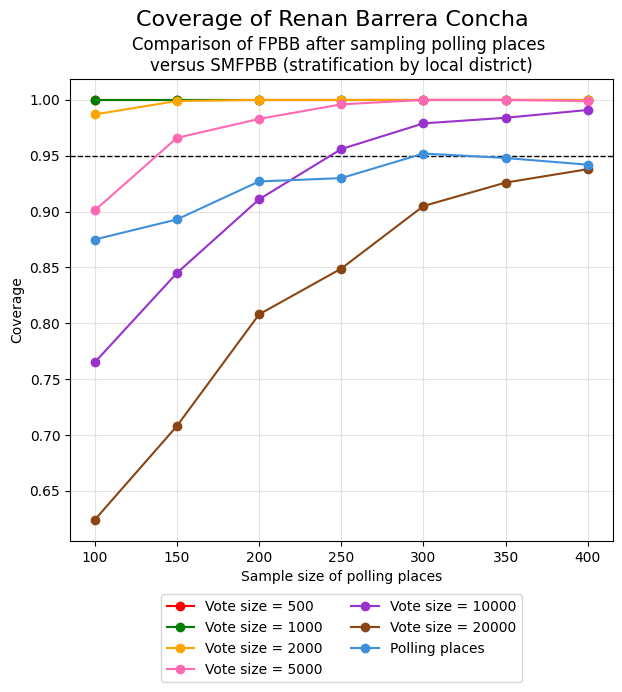

In [44]:
# Tamaño de la gráfica
fig = plt.figure(figsize=(7, 6), dpi=100)
# Para guardar la gráfica
#fig = plt.figure(figsize=(7, 6), dpi=300)

# Colores para la gráfica
colors_plot = ["red", "green", "orange", "hotpink", "darkorchid", "saddlebrown", "mediumturquoise"]
plt.axhline(y=0.95, linewidth=1, color='black', ls='--');
l=0
# Para graficar todos las rectas de los votos
for ind_j, j in enumerate(df_boostraps_votos_est["Tamaño_submuestra_votos"].unique()):     
        plt.plot(df_boostraps_votos_est[(df_boostraps_votos_est["Tamaño_submuestra_votos"] == j)]["Tamaño_muestra_casillas"], 
                 df_boostraps_votos_est[(df_boostraps_votos_est["Tamaño_submuestra_votos"] == j)]["Cob_RENAN_BARRERA_CONCHA"],
                 color=colors_plot[ind_j], label=f'Vote size = {j}', linestyle='solid',  marker='o')
        
# La gráfica de las casillas
plt.plot(df_boostraps_c_est["Tamaño_muestra_casillas"], df_boostraps_c_est["Cob_RENAN_BARRERA_CONCHA"], color='C0', marker='o', label='Polling places')

plt.suptitle('Coverage of Renan Barrera Concha', fontsize=16, y=0.995)
plt.title('Comparison of FPBB after sampling polling places \nversus SMFPBB (stratification by local district)');
plt.ylabel(ylabel='Coverage');
plt.xlabel('Sample size of polling places')

# Juntamos los títulos y las leyendas con un nombre
plt.legend(bbox_to_anchor=(0.5, -0.1), loc="upper center", shadow=False, ncol=2);

plt.grid(alpha=0.35);
plt.savefig(r"/Users/damian/Documents/Tesis maestria/Imagenes/Casillas_vs_casillas_sub_votos_m_2/Estratificado/Renan_Barrera_Concha_casillas_sub_votos_vs_casillas_m_2_est.png", bbox_inches='tight',dpi=300);

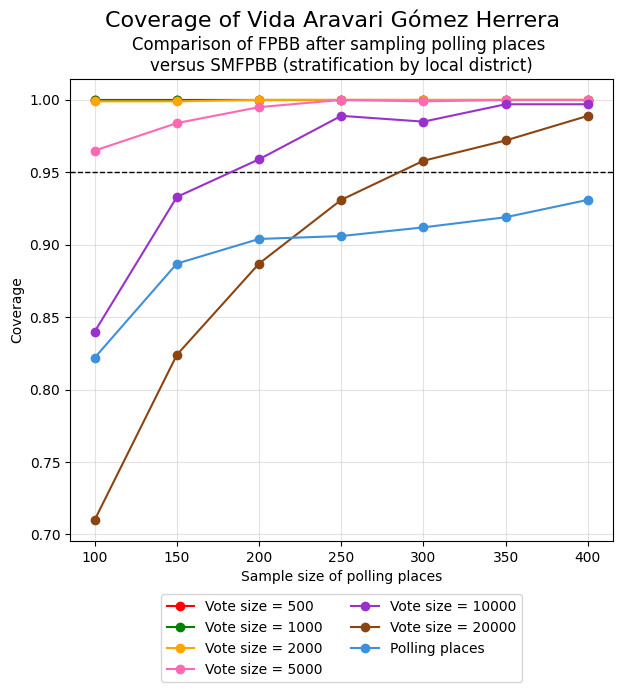

In [46]:
# Tamaño de la gráfica
fig = plt.figure(figsize=(7, 6), dpi=100)
# Para guardar la imagen
#fig = plt.figure(figsize=(7, 6), dpi=300)

# Colores para la gráfica
colors_plot = ["red", "green", "orange", "hotpink", "darkorchid", "saddlebrown", "mediumturquoise"]
plt.axhline(y=0.95, linewidth=1, color='black', ls='--');
l=0
# Para graficar todos las rectas de los votos
for ind_j, j in enumerate(df_boostraps_votos_est["Tamaño_submuestra_votos"].unique()):     
        plt.plot(df_boostraps_votos_est[(df_boostraps_votos_est["Tamaño_submuestra_votos"] == j)]["Tamaño_muestra_casillas"], 
                 df_boostraps_votos_est[(df_boostraps_votos_est["Tamaño_submuestra_votos"] == j)]["Cob_VIDA_ARAVARI_GOMEZ_HERRERA"],
                 color=colors_plot[ind_j], label=f'Vote size = {j}', linestyle='solid',  marker='o')
        
# La gráfica de las casillas
plt.plot(df_boostraps_c_est["Tamaño_muestra_casillas"], df_boostraps_c_est["Cob_VIDA_ARAVARI_GOMEZ_HERRERA"], color='C0', marker='o', label='Polling places')

plt.suptitle('Coverage of Vida Aravari Gómez Herrera', fontsize=16, y=0.995)
plt.title('Comparison of FPBB after sampling polling places \nversus SMFPBB (stratification by local district)');
plt.ylabel(ylabel='Coverage');
plt.xlabel('Sample size of polling places')

# Juntamos los títulos y las leyendas con un nombre
plt.legend(bbox_to_anchor=(0.5, -0.1), loc="upper center", shadow=False, ncol=2);

plt.grid(alpha=0.35);
plt.savefig(r"/Users/damian/Documents/Tesis maestria/Imagenes/Casillas_vs_casillas_sub_votos_m_2/Estratificado/Vida_Aravari_Gomez_Herrera_casillas_sub_votos_vs_casillas_m_2_est.png", bbox_inches='tight',dpi=300);

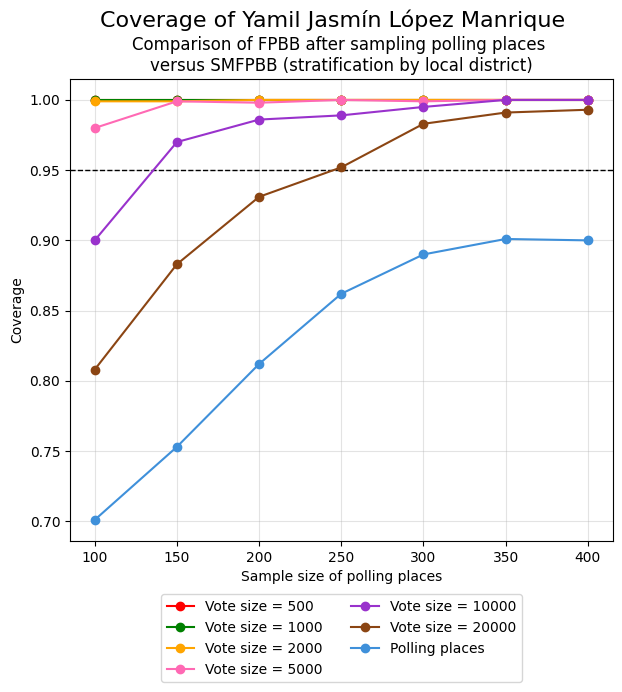

In [48]:
# Tamaño de la gráfica
fig = plt.figure(figsize=(7, 6), dpi=100)
# Para guardar la imagen
#fig = plt.figure(figsize=(7, 6), dpi=300)

# Colores para la gráfica
colors_plot = ["red", "green", "orange", "hotpink", "darkorchid", "saddlebrown", "mediumturquoise"]
plt.axhline(y=0.95, linewidth=1, color='black', ls='--');
l=0
# Para graficar todos las rectas de los votos
for ind_j, j in enumerate(df_boostraps_votos_est["Tamaño_submuestra_votos"].unique()):     
        plt.plot(df_boostraps_votos_est[(df_boostraps_votos_est["Tamaño_submuestra_votos"] == j)]["Tamaño_muestra_casillas"], 
                 df_boostraps_votos_est[(df_boostraps_votos_est["Tamaño_submuestra_votos"] == j)]["Cob_YAMIL_JASMIN_LOPEZ_MANRIQUE"],
                 color=colors_plot[ind_j], label=f'Vote size = {j}', linestyle='solid',  marker='o')
        
# La gráfica de las casillas
plt.plot(df_boostraps_c_est["Tamaño_muestra_casillas"], df_boostraps_c_est["Cob_YAMIL_JASMIN_LOPEZ_MANRIQUE"], color='C0', marker='o', label='Polling places')

plt.suptitle('Coverage of Yamil Jasmín López Manrique', fontsize=16, y=0.995)
plt.title('Comparison of FPBB after sampling polling places \nversus SMFPBB (stratification by local district)');
plt.ylabel(ylabel='Coverage');
plt.xlabel('Sample size of polling places')

# Juntamos los títulos y las leyendas con un nombre
plt.legend(bbox_to_anchor=(0.5, -0.1), loc="upper center", shadow=False, ncol=2);

plt.grid(alpha=0.35);
plt.savefig(r"/Users/damian/Documents/Tesis maestria/Imagenes/Casillas_vs_casillas_sub_votos_m_2/Estratificado/Jasmin_Lopez_Manrique_casillas_sub_votos_vs_casillas_m_2_est.png", bbox_inches='tight',dpi=300);

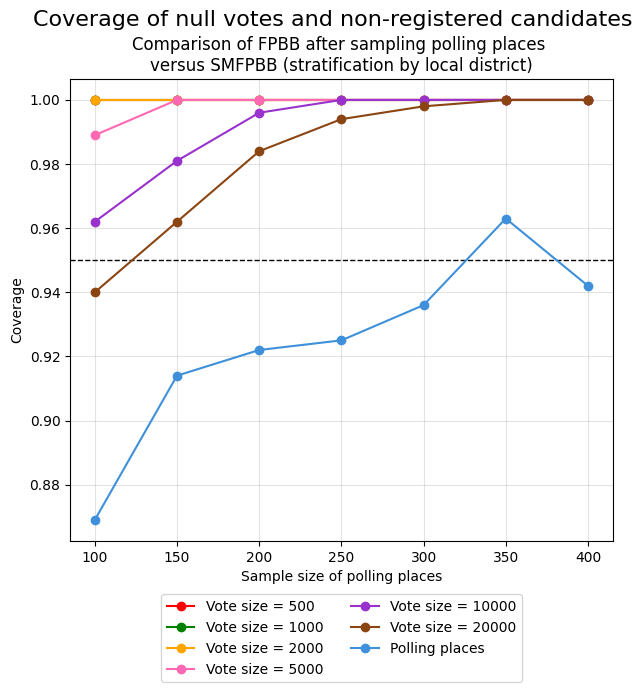

In [50]:
# Tamaño de la gráfica
fig = plt.figure(figsize=(7, 6), dpi=100)
# Para guardar la imagen
#fig = plt.figure(figsize=(7, 6), dpi=300)

# Colores para la gráfica
colors_plot = ["red", "green", "orange", "hotpink", "darkorchid", "saddlebrown", "mediumturquoise"]
plt.axhline(y=0.95, linewidth=1, color='black', ls='--');
l=0
# Para graficar todos las rectas de los votos
for ind_j, j in enumerate(df_boostraps_votos_est["Tamaño_submuestra_votos"].unique()):     
        plt.plot(df_boostraps_votos_est[(df_boostraps_votos_est["Tamaño_submuestra_votos"] == j)]["Tamaño_muestra_casillas"], 
                 df_boostraps_votos_est[(df_boostraps_votos_est["Tamaño_submuestra_votos"] == j)]["Cob_VOTOS_NULOS_CAND_NO_REGIS"],
                 color=colors_plot[ind_j], label=f'Vote size = {j}', linestyle='solid',  marker='o')
        
# La gráfica de las casillas
plt.plot(df_boostraps_c_est["Tamaño_muestra_casillas"], df_boostraps_c_est["Cob_VOTOS_NULOS_CAND_NO_REGIS"], color='C0', marker='o', label='Polling places')

plt.suptitle('Coverage of null votes and non-registered candidates', fontsize=16, y=0.995)
plt.title('Comparison of FPBB after sampling polling places \nversus SMFPBB (stratification by local district)');
plt.ylabel(ylabel='Coverage');
plt.xlabel('Sample size of polling places')

# Juntamos los títulos y las leyendas con un nombre
plt.legend(bbox_to_anchor=(0.5, -0.1), loc="upper center", shadow=False, ncol=2);

plt.grid(alpha=0.35);
plt.savefig(r"/Users/damian/Documents/Tesis maestria/Imagenes/Casillas_vs_casillas_sub_votos_m_2/Estratificado/Votos_nulos_no_reg_casillas_sub_votos_vs_casillas_m_2_est.png", bbox_inches='tight',dpi=300);